# 我使用了什么库？

In [97]:
# 将项目根目录添加到系统路径，以便导入项目中的自定义模块
import sys, os
sys.path.insert(0, os.path.abspath('..'))

In [98]:
# 设置Jupyter Notebook的显示样式，将容器宽度限制为80%
from IPython.display import display, HTML
display(HTML("<style>.container { width:80% !important; }</style>"))

In [99]:
# ============================================================
# 基础科学计算和图像处理库
# ============================================================
import numpy as np                    # 数值计算库，提供多维数组支持
from PIL import Image                 # 图像读取与处理
from copy import deepcopy             # 深拷贝，用于模型复制

# ============================================================
# PyTorch 核心库
# ============================================================
import torch                          # PyTorch 深度学习框架
import torch.optim as optim           # 优化器模块（SGD, Adam 等）
import torch.nn as nn                 # 神经网络模块（层、损失函数等）
import torch.nn.functional as F       # 函数式API（激活函数、池化等）

# ============================================================
# 数据加载与预处理
# ============================================================
from torch.utils.data import DataLoader, TensorDataset, random_split
# DataLoader: 批量加载数据，支持多线程
# TensorDataset: 将张量包装为数据集
# random_split: 随机划分数据集

# ============================================================
# torchvision 图像变换与数据集
# ============================================================
from torchvision.transforms.v2 import Compose, ToImage, Normalize, \
ToPILImage, Resize, ToDtype
# Compose: 组合多个变换
# ToImage: 将数据转换为图像张量
# Normalize: 图像标准化
# ToPILImage: 张量转PIL图像
# Resize: 调整图像大小
# ToDtype: 转换数据类型

from torchvision.datasets import ImageFolder
# ImageFolder: 按文件夹分类加载图像数据集

# ============================================================
# 学习率调度器
# ============================================================
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau, \
MultiStepLR, CyclicLR, LambdaLR
# StepLR: 等间隔调整学习率
# ReduceLROnPlateau: 指标停滞时降低学习率
# MultiStepLR: 在指定epoch调整学习率
# CyclicLR: 循环学习率
# LambdaLR: 自定义函数调整学习率
# ============================================================
# 项目自定义模块
# ============================================================
from StepClass.v2 import StepByStep   # 训练流程封装类
from data_generation.rps import download_rps  # 下载石头剪刀布数据集

from plots.chapter6 import *           # 第6章绘图函数

In [100]:
plt.style.available

['Solarize_Light2',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'petroff6',
 'petroff8',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

# 然后，我要干什么？

首先要了解下问题的样子

然后了解如何准备相关数据


# 剪刀石头布问题

- 2892个不同手势图像，合成数据集,300x300像素，4个通道RGBA
- 训练集2520图像(rpc)，测试集372图像(rpc-test-set)
- 数据集是完全平衡的

rps folder already exists!
rps-test-set folder already exists!


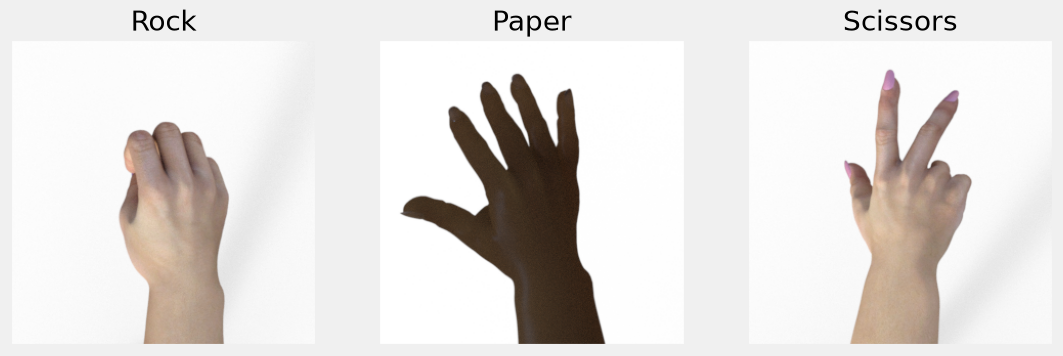

In [101]:
# 下载图片
# 详细逻辑参考bypass
download_rps()

# 展示结果
fig = figure1()

# 数据准备


**Q**: `ImageFolder`需要如何组织数据?

结合代码

**Q**: ImageFolder的参数有那些？

In [102]:
# 程序6-1: ImageFolder的使用和参数
temp_transform = Compose(
    [Resize(28)
     , ToImage()
     , ToDtype(torch.float32, scale=True)
])
temp_dataset = ImageFolder(root='rps', transform=temp_transform)

## 标准化

**Q**: 迁移学习是如何标准化的？

结合代码: 

**Q**: 如何对图片进行标准化?

In [103]:
# 程序6-2 标准化: 统计数量,均值,标准差
@staticmethod
def statistics_per_channel(images, labels):
    n_samples, n_channels, n_height, n_weight = images.size()  # NCHW（批次、通道、高度、宽度）
    #print(n_samples,n_channels,n_height,n_weight) # 16 3 28 28
    flatten_per_channel = images.reshape(n_samples, n_channels, -1)  # 将高和宽展平为单一维度
    #print(flatten_per_channel.shape) #torch.Size([16, 3, 784])

    # 计算每个图像在各通道上的统计信息
    means = flatten_per_channel.mean(axis=2)  # 每个通道的平均像素值 (样本数, 通道数)
    #print(means.shape) # torch.Size([16, 3])

    stds = flatten_per_channel.std(axis=2)  # 每个通道的像素值标准差 (样本数, 通道数)

    # 累加小批量中所有图像的统计信息
    sum_means = means.sum(axis=0)  # (1, 通道数)
    #print(sum_means.shape) # torch.Size([3])
    sum_stds = stds.sum(axis=0)
    # 注意其中的乘号语法
    n_samples = torch.tensor([n_samples]*n_channels).float()  # 创建(1, 通道数)张量，包含小批量中的样本数量
    #print(n_samples)
    
    # 返回数量，均值，标准差
    #print(np.array([n_samples, sum_means, sum_stds]))
    return torch.stack([n_samples, sum_means, sum_stds], axis=0)  # 将三个张量沿第0维堆叠 (3, 通道数)

setattr(StepByStep, 'statistics_per_channel', statistics_per_channel)

In [104]:
# 测试结果

# 临时loader
temp_loader = DataLoader(temp_dataset,batch_size=16)

first_images,first_labels = next(iter(temp_loader))

print(first_images.shape,first_labels.shape)

print(StepByStep.statistics_per_channel(first_images,first_labels))


torch.Size([16, 3, 28, 28]) torch.Size([16])
tensor([[16.0000, 16.0000, 16.0000],
        [13.8748, 13.3048, 13.1962],
        [ 3.0507,  3.8268,  3.9754]])


In [105]:
# 程序6-3: 标准化: 创建标准化器

@staticmethod
def make_normalizer(loader):
    # 对每个批次使用统计函数
    total_samples, total_means, total_stds = StepByStep.loader_apply(loader, StepByStep.statistics_per_channel)
    # 对所有批次的总和求平均
    norm_mean = total_means / total_samples
    norm_std = total_stds / total_samples
    return Normalize(mean=norm_mean, std=norm_std)

setattr(StepByStep, 'make_normalizer', make_normalizer)

In [106]:
# 测试结果

normalizer = StepByStep.make_normalizer(temp_loader)

print(normalizer)

Normalize(mean=[tensor(0.8502), tensor(0.8215), tensor(0.8116)], std=[tensor(0.2089), tensor(0.2512), tensor(0.2659)], inplace=False)


## 真实数据集

**Q**: 标准化使用哪部分的数据？

结合代码: 

**Q**: 如何对图片进行标准化?

In [107]:
# 程序6-4: 利用生成标准化器标准化图片

# 将图片转为张量并标准化
composer = Compose([Resize(28),
                    ToImage(),
                    ToDtype(torch.float32, scale=True),
                    normalizer])

# 构建DataSet
train_data = ImageFolder(root='rps', transform=composer)
val_data = ImageFolder(root='rps-test-set', transform=composer)

# 构建loader
# 注意打乱数据
print(len(train_data.imgs))
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16)

print(len(train_loader),len(val_loader))

2520
158 24


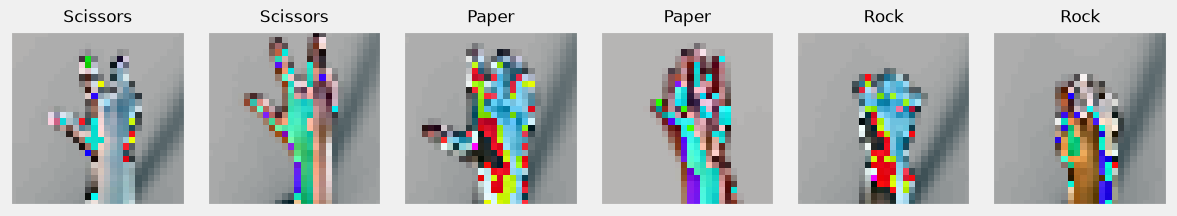

In [108]:
# 测试结果

torch.manual_seed(88)
first_images, first_labels = next(iter(train_loader))

fig = figure2(first_images, first_labels)

# 然后，我要干什么？

注意到现在处理的是三通道数据，结合上一张的卷积知识，自然想到三通道的卷积应该怎么做？


# 三通道卷积

**Q**: 多通道卷积的计算方式是什么？

**Q**: 多个多通道滤波器会产生什么结果？

结合代码:

**Q**: 如何使用卷积计算?

In [109]:
# 程序6-5: 模拟三通道卷积的计算

# 数据
regions = np.array([[[[5, 0, 8],
                      [1, 9, 5],
                      [6, 0, 2]],
                     [[0, 5, 4],
                      [8, 1, 9],
                      [4, 8, 1]],
                     [[4, 2, 0],
                      [6, 3, 0],
                      [5, 2, 8]]]])
print(regions.shape)

# 滤波器
three_channel_filter = np.array([[[[0, 3, 0],
                                   [1, 0, 1],
                                   [2, 1, 0]],
                                  [[2, 1, 0],
                                   [0, 3, 1],
                                   [1, -1, 0]],
                                  [[0, 1, 3],
                                   [-1, -2, 0],
                                   [2, 0, 1]]]])
print(three_channel_filter.shape)


# 函数式应用
result = F.conv2d(torch.as_tensor(regions), torch.as_tensor(three_channel_filter))
print(result, result.shape)

(1, 3, 3, 3)
(1, 3, 3, 3)
tensor([[[[39]]]]) torch.Size([1, 1, 1, 1])


# BTW(By the way)

按理应该利用卷积+池化+激活函数创建一个模型类，但是先要了解一个通用的概念：DropOut

# 丢弃: DropOut

**Q**: 正则化的思想是什么？

**Q**: 丢弃是什么？其目的是什么？



结合代码:

**Q**: 如何使用DropOut? 

**Q**: Dropout 在训练模式下做了哪两件事？为什么要这么做？

**Q**: 丢弃的对象是什么？权重还是输入？


---



In [110]:
# 程序6-6: DropOut的使用

# 设定丢弃概率
# F.dropout
dropping_model = nn.Sequential(nn.Dropout(p=0.5))

# 创建等距的分割
spaced_points = torch.linspace(.1, 1.1, 11)
print(spaced_points)

torch.manual_seed(44)

# 注意要切换模式
dropping_model.train()

# 测试结果: 随机丢弃
output_train = dropping_model(spaced_points)
print(output_train)

tensor([0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000, 0.9000,
        1.0000, 1.1000])
tensor([0.0000, 0.0000, 0.6000, 0.8000, 0.0000, 0.0000, 1.4000, 0.0000, 1.8000,
        2.0000, 2.2000])


In [111]:
# 程序6-7: 计算dropOut的缩放倍率

print(output_train/spaced_points)

tensor([0., 0., 2., 2., 0., 0., 2., 0., 2., 2., 2.])


In [112]:
# 程序6-8: DropOut的评价模式


dropping_model.eval()
output_eval = dropping_model(spaced_points)
print(output_eval)


tensor([0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000, 0.9000,
        1.0000, 1.1000])


## DropOut下的分布

结合图:

**Q**: 模型学习的数值分布以什么为中心？

**Q**: DropOut率对输出形状的影响？


In [113]:
# 对比训练和评价模式的分布

print(F.linear(output_train, weight=torch.ones(11), bias=torch.tensor(0)))

print(F.linear(output_eval, weight=torch.ones(11), bias=torch.tensor(0)))


tensor(8.8000)
tensor(6.6000)


In [114]:
# 统计DropOut的分布情况: 生成数据

torch.manual_seed(17)
p = 0.5

# 列表推导式，生成1000次dropout场景，统计分布
distrib_outputs = torch.tensor(
    [F.linear(F.dropout(spaced_points, p=p)
              ,weight=torch.ones(11), bias=torch.tensor(0))
                for _ in range(1000)
    ])

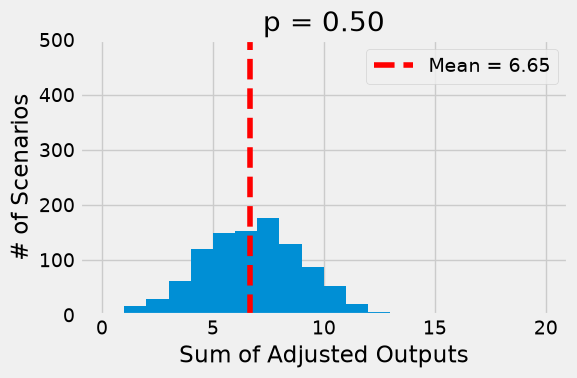

In [115]:
# 统计DropOut的分布情况: 作图
fig = figure7(p, distrib_outputs)

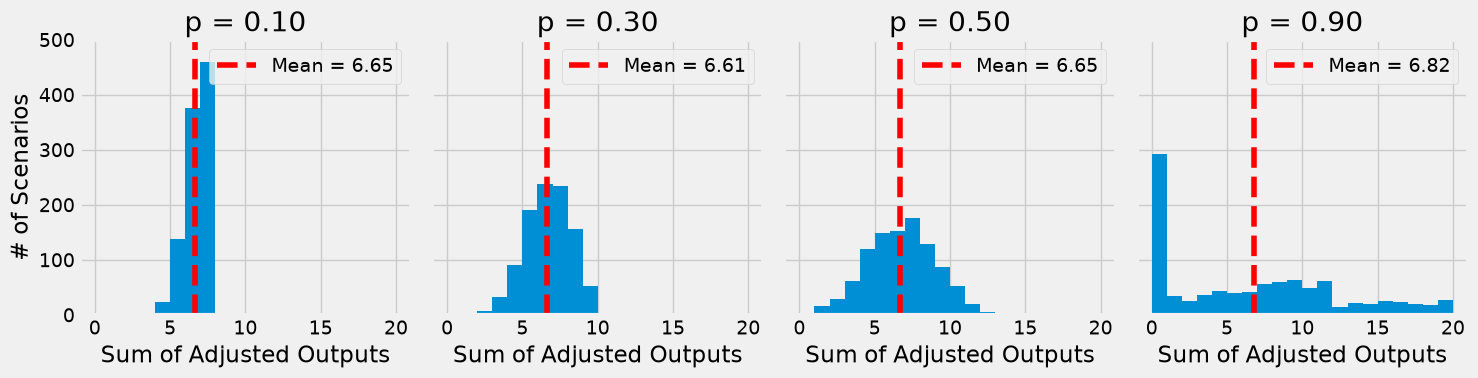

In [116]:
# 不同DropOut率对结果的影响
fig = figure8()

## 二维DropOut

**Q**: 在卷积过程中丢弃的对象是什么？

**Q**: 和普通DropOut的区别是什么？表现上有什么区别？

**Q**: 使用的类是什么？


torch.Size([1, 3, 28, 28])


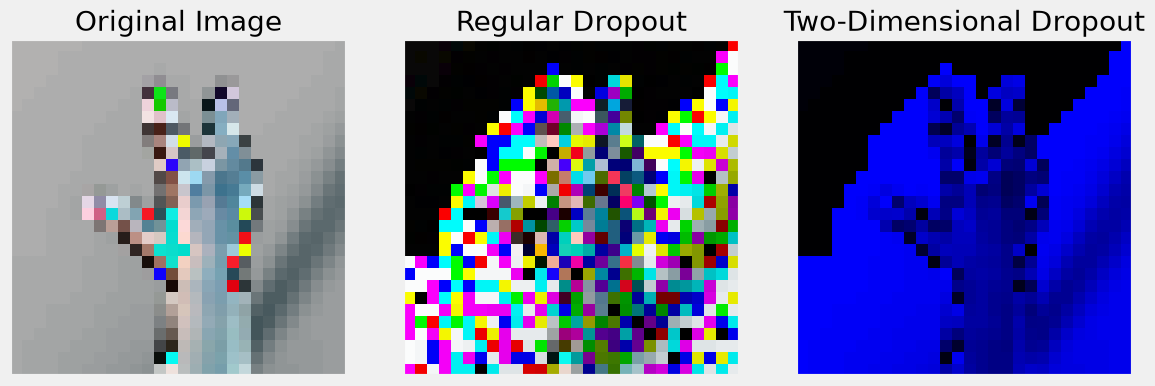

In [117]:
# 展示丢弃
print(first_images[:1].shape)
fig = figure9(first_images)

# 然后，我要干什么？

回到正题，现在可以更新一个处理图像的模型类了

# 更高级的模型

结合代码:

**Q**: 卷积的前向传播有哪些步骤？具体步骤是什么？

In [118]:
# 程序6-9: CNN2模型定义

class CNN2(nn.Module):
    def __init__(self, n_feature, p=0.0):
        super(CNN2, self).__init__()
        self.n_feature = n_feature
        self.p = p
        # 创建卷积层
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=n_feature, kernel_size=3)
        self.conv2 = nn.Conv2d(in_channels=n_feature, out_channels=n_feature, kernel_size=3)
        # 创建全连接层
        # 这个 5 * 5 从哪来的？！看下面
        self.fc1 = nn.Linear(n_feature * 5 * 5, 50) 
        self.fc2 = nn.Linear(50, 3)
        # 创建 Dropout 层
        self.drop = nn.Dropout(self.p)
        
    def featurizer(self, x):
        # 特征提取器
        # 第一个卷积块
        # 3@28x28 -> n_feature@26x26 -> n_feature@13x13
        x = self.conv1(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)
        # 第二个卷积块
        # n_feature@13x13 -> n_feature@11x11 -> n_feature@5x5
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)
        # 拉平
        # 输入维度 (n_feature@5x5)
        # 输出维度 (n_feature * 5 * 5)
        x = nn.Flatten()(x)
        return x
    
    def classifier(self, x):
        # 分类器
        # 隐藏层
        # 输入维度 (n_feature * 5 * 5)
        # 输出维度 (50)
        if self.p > 0:
            x = self.drop(x)
        x = self.fc1(x)
        x = F.relu(x)
        # 输出层
        # 输入维度 (50)
        # 输出维度 (3)
        if self.p > 0:
            x = self.drop(x)
        x = self.fc2(x)
        return x
                
    # 前向预测
    def forward(self, x):
        x = self.featurizer(x) # 特征提取(展平)
        x = self.classifier(x) # 分类
        return x

# 模型配置

计划: 滤波器5个，30%丢失概率，交叉熵误差

**暂时搁置（见稍后BTW）**: 放弃使用SGD优化器，使用Adam进行更改（自适应学习率）

**Q**: 模型配置的内容有哪些？

**Q**: Karpathy常数是什么？多少？

结合代码:

**Q**: 模型,优化器和误差函数如何使用？



In [119]:
# 程序6-10: 模型配置

torch.manual_seed(13)
model_cnn2 = CNN2(n_feature=5, p=0.3)
multi_loss_fn = nn.CrossEntropyLoss(reduction='mean')
optimizer_cnn2 = optim.Adam(model_cnn2.parameters(), lr=3e-4)

# 模型训练

结合代码：

**Q**: 如何使用模型训练？

**Q**: 如何绘制损失？

In [120]:
# 程序6-11: 模型训练

sbs_cnn2 = StepByStep(model_cnn2, multi_loss_fn, optimizer_cnn2)
sbs_cnn2.set_loaders(train_loader, val_loader)
sbs_cnn2.train(10)

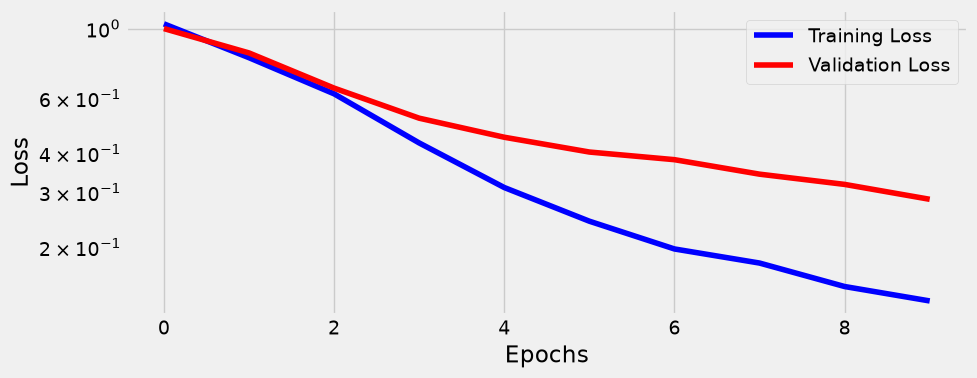

In [121]:
# 程序6-12: 测试损失
fig = sbs_cnn2.plot_losses()

In [122]:
# 程序6-13: 准确率

# 372中317个 85.2%
StepByStep.loader_apply(val_loader, sbs_cnn2.correct)

tensor([[ 88, 124],
        [118, 124],
        [111, 124]])

## 对比DropOut的效果


结合图和准确率数据

**Q**: 丢弃的正则化效果是如何表现的？

**Q**: 没有丢弃的模型，对于训练数据会发生什么？

In [123]:
# 建立非Drop的模型

torch.manual_seed(13)
# Model Configuration
model_cnn2_nodrop = CNN2(n_feature=5, p=0.0)
multi_loss_fn = nn.CrossEntropyLoss(reduction='mean')
optimizer_cnn2_nodrop = optim.Adam(model_cnn2_nodrop.parameters(), lr=3e-4)
# Model Training
sbs_cnn2_nodrop = StepByStep(model_cnn2_nodrop, multi_loss_fn, optimizer_cnn2_nodrop)
sbs_cnn2_nodrop.set_loaders(train_loader, val_loader)
sbs_cnn2_nodrop.train(10)

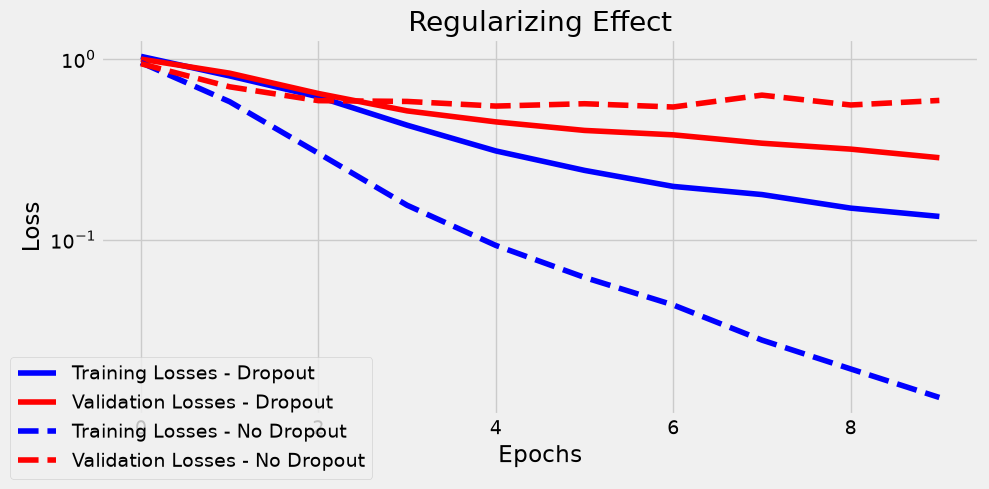

In [124]:
# 对比结果
fig = figure11(sbs_cnn2.losses, sbs_cnn2.val_losses, sbs_cnn2_nodrop.losses, sbs_cnn2_nodrop.val_losses)

In [125]:
# 对比准确率
print(
    StepByStep.loader_apply(train_loader, sbs_cnn2_nodrop.correct).sum(axis=0), 
    StepByStep.loader_apply(val_loader, sbs_cnn2_nodrop.correct).sum(axis=0)
)

print(
    StepByStep.loader_apply(train_loader, sbs_cnn2.correct).sum(axis=0),
    StepByStep.loader_apply(val_loader, sbs_cnn2.correct).sum(axis=0)
)

tensor([2520, 2520]) tensor([293, 372])
tensor([2498, 2520]) tensor([317, 372])


# 可视化滤波器

结合输出:

**Q**：解释滤波器形状变化的意思？

In [126]:
# 滤波器形状
print(model_cnn2.conv1.weight.shape) # 3->5

print(model_cnn2.conv2.weight.shape) # 5->5

torch.Size([5, 3, 3, 3])
torch.Size([5, 5, 3, 3])


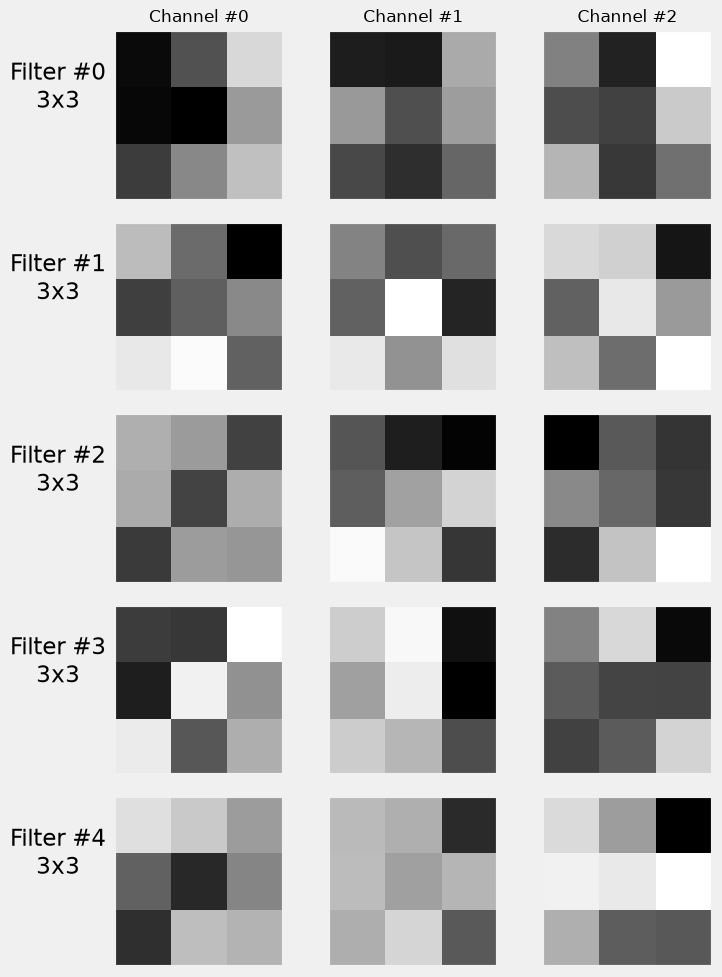

In [127]:
# 可视化滤波器1
fig = sbs_cnn2.visualize_filters('conv1')

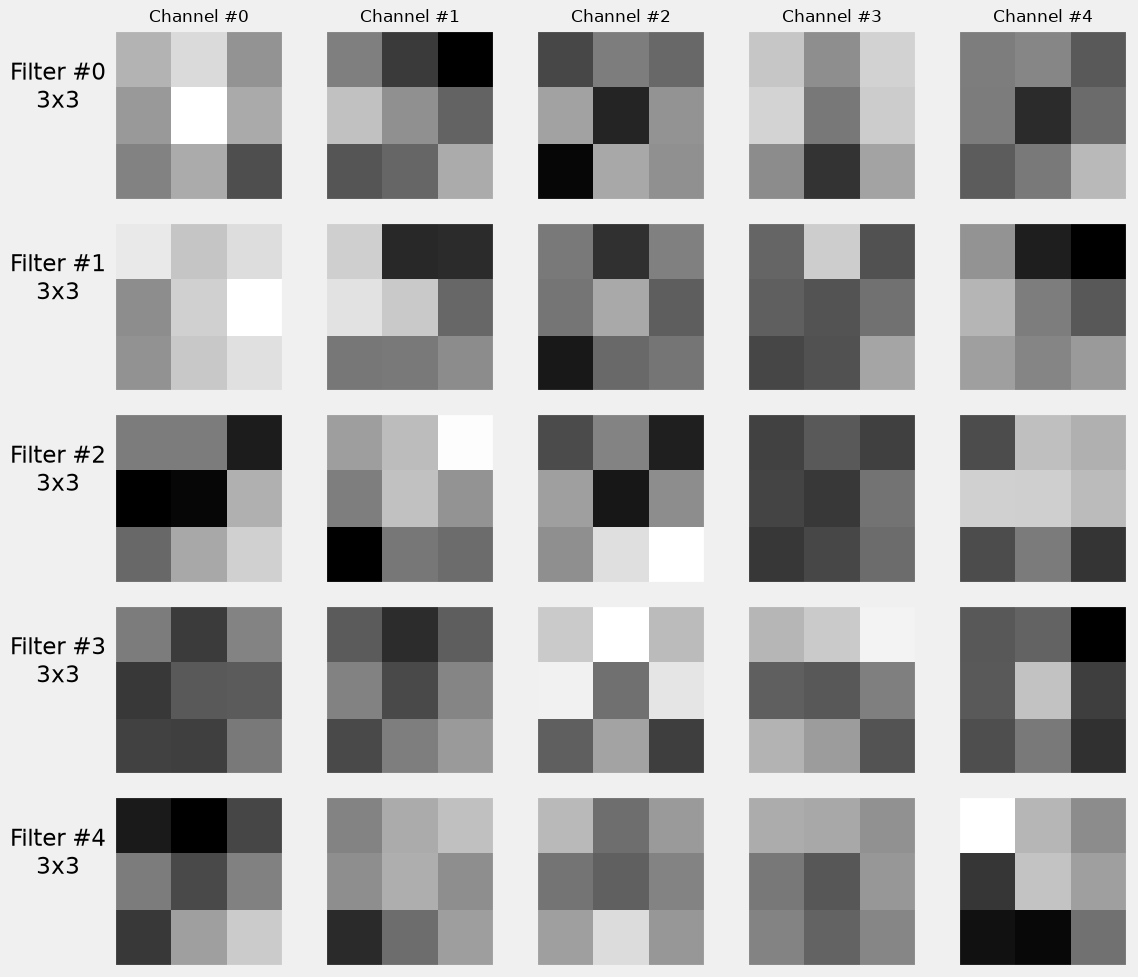

In [128]:
# 可视化滤波器2
fig = sbs_cnn2.visualize_filters('conv2')

# BTW（By The Way）

接下来要研究学习率，包括优化器`Adam`和`SGD`，和学习率的各种计算

# 学习率

**Q**: 学习率影响的是什么？

**Q**: 如何找到合适的学习率？

----

**Q**: 如何使用网格搜索？各个结果的意义是什么？

## 寻找LR

**Q**: 什么是LR范围测试？和网格搜索有什么区别？

结合代码:

**Q**: 解释`make_lr_fn`相关参数的意义

**Q**: 解释`make_lr_fn`中指数增长的行为的特点

**Q**: 如何使用`make_lr_fn`生成的函数？

In [129]:
# 程序6-15: 学习率乘数函数生成器
# 该函数用于 LR 范围测试（LR Range Test）：通过从一个很小的学习率开始，
# 逐步增大学习率，观察损失的变化，从而找到合适的学习率范围。
#
# 返回值是一个 LambdaLR 可用的乘数函数 lr_fn(iteration)，
# 实际学习率 = base_lr * lr_fn(iteration)

def make_lr_fn(start_lr, end_lr, num_iter, step_mode='exp'):
    # start_lr: 起始学习率（通常很小，如 1e-6）
    # end_lr:   终止学习率（通常较大，如 1）
    # num_iter: 迭代总次数（即经过多少次迭代从 start_lr 到达 end_lr）
    # step_mode: 增长模式 — 'linear' 线性增长 或 'exp' 指数增长

    if step_mode == 'linear':
        # 线性模式：每一步的乘数增量是固定的
        # factor = (end_lr/start_lr - 1) / num_iter
        # 例如 start_lr=0.001, end_lr=1, num_iter=100
        #   → factor = (1000 - 1) / 100 = 9.99
        # 迭代0: 1 + 0*9.99 = 1      → 实际 lr = 0.001
        # 迭代1: 1 + 1*9.99 = 10.99  → 实际 lr ≈ 0.011
        # 迭代99: 1 + 99*9.99 ≈ 990  → 实际 lr ≈ 0.99
        factor = (end_lr / start_lr - 1) / num_iter
        def lr_fn(iteration):
            return 1 + iteration * factor
    else:
        # 指数模式（默认）：每一步乘以一个固定的倍数
        # 在对数空间中均匀分布：log(lr) 从 log(start_lr) 线性增长到 log(end_lr)
        # factor = (ln(end_lr) - ln(start_lr)) / num_iter
        # 例如 start_lr=0.001, end_lr=1, num_iter=100
        #   → factor = (0 - (-6.9078)) / 100 ≈ 0.06908
        # lr_fn(iteration) = exp(factor)^iteration = exp(factor * iteration)
        # 迭代0: exp(0) = 1             → 实际 lr = 0.001
        # 迭代1: exp(0.06908) ≈ 1.0715 → 实际 lr ≈ 0.00107
        # 迭代99: exp(6.838) ≈ 933     → 实际 lr ≈ 0.933
        factor = (np.log(end_lr) - np.log(start_lr)) / num_iter
        def lr_fn(iteration):
            return np.exp(factor)**iteration    # 等价于 exp(factor * iteration)
    return lr_fn

In [130]:
# 程序6-16: 学习率函数的使用

start_lr = 0.01
end_lr = 0.1
num_iter = 10
lr_fn = make_lr_fn(start_lr, end_lr, num_iter, step_mode='exp')

# 生成边界范围内的所有倍率
print(lr_fn(np.arange(num_iter + 1)))

# 计算边界范围内的所有学习率
print(start_lr * lr_fn(np.arange(num_iter + 1)))

[ 1.          1.25892541  1.58489319  1.99526231  2.51188643  3.16227766
  3.98107171  5.01187234  6.30957344  7.94328235 10.        ]
[0.01       0.01258925 0.01584893 0.01995262 0.02511886 0.03162278
 0.03981072 0.05011872 0.06309573 0.07943282 0.1       ]


## 更新优化器

结合代码

**Q**: 什么是调度器？

**Q**: 如何使用调度器？有什么注意事项？

---


In [131]:
# 程序6-17: 调度器的使用

# 声明调度器和优化器
dummy_model = CNN2(n_feature=5, p=0.3)
dummy_optimizer = optim.Adam(dummy_model.parameters(), lr=start_lr)
dummy_scheduler = LambdaLR(dummy_optimizer, lr_lambda=lr_fn)

# 调度器的使用和注意
dummy_optimizer.step()
dummy_scheduler.step()


In [132]:
# 测试结果：检查学习率

dummy_scheduler.get_last_lr()[0]

np.float64(0.012589254117941673)

## LR范围测试

**暂时搁置(BTW)**: 指数移动平均（EMA）平滑损失


**Q**: 如果一开始就拿到好的学习率，会顺利完成训练嘛？

结合代码：

**Q**: 如何使用LR范围测试找寻合适的学习率？（分步骤陈述）

**Q**: 预期的图像应该如何？如何评价结果图像？什么区域是应该瞄准的区域？

**Q**: EWMA的作用是？



In [133]:
# 程序6-18: LR 范围测试（LR Range Test）
# 该方法实现 Leslie Smith 提出的学习率范围测试：
# 从一个较小的起始学习率开始，逐步（线性或指数）增大学习率，
# 同时记录每个学习率对应的损失值，最后绘制"学习率-损失"曲线。
# 曲线的拐点（损失下降最快处）或损失最小值点，即为推荐的初始学习率。
#
# 参数说明：
#   data_loader: 用于测试的数据加载器（通常是训练集）
#   end_lr:      测试的终止学习率
#   num_iter:    测试的总迭代次数（默认100）
#   step_mode:   学习率增长模式 — 'exp'指数（默认）或 'linear'线性
#   alpha:       损失平滑系数（0~1），用于减少批次间的噪声抖动
#   ax:          可选的matplotlib坐标轴，用于将图绘制到已有图表上
def lr_range_test(self, data_loader, end_lr, num_iter=100, step_mode='exp', alpha=0.05, ax=None):
    # ----------------------------------------------------------------
    # 第一步：保存当前的模型和优化器状态
    # 因为范围测试会修改模型参数（通过多次训练步骤），
    # 测试完成后需要恢复到测试前的状态
    # ----------------------------------------------------------------
    previous_states = {'model': deepcopy(self.model.state_dict()), 
                       'optimizer': deepcopy(self.optimizer.state_dict())}
    
    # 从优化器中取出当前设置的学习率，作为范围测试的起始学习率
    start_lr = self.optimizer.state_dict()['param_groups'][0]['lr']
    
    # ----------------------------------------------------------------
    # 第二步：构建学习率乘数函数和对应的调度器
    # lr_fn 每个迭代返回一个乘数，LambdaLR 将其与 base_lr 相乘得到实际学习率
    # ----------------------------------------------------------------
    lr_fn = make_lr_fn(start_lr, end_lr, num_iter)
    scheduler = LambdaLR(self.optimizer, lr_lambda=lr_fn)

    # 用于记录每次迭代的学习率和（平滑后的）损失值
    tracking = {'loss': [], 'lr': []}
    iteration = 0

    # ----------------------------------------------------------------
    # 第三步：执行范围测试循环
    # 如果 num_iter 大于 data_loader 的批次数，则需要多次遍历 data_loader
    # ----------------------------------------------------------------
    while (iteration < num_iter):
        # 标准的 mini-batch 内循环：遍历数据加载器中的每个批次
        for x_batch, y_batch in data_loader:
            # 将数据移动到指定设备（GPU/CPU）
            x_batch = x_batch.to(self.device)
            y_batch = y_batch.to(self.device)
            
            # 训练四步曲：
            # Step 1 — 前向传播：计算预测值
            yhat = self.model(x_batch)
            # Step 2 — 计算损失
            loss = self.loss_fn(yhat, y_batch)
            # Step 3 — 反向传播：计算梯度
            loss.backward()

            # ----------------------------------------------------------------
            # 记录当前学习率和平滑后的损失值
            # 使用指数移动平均（EMA）平滑损失：有助于减少批次间的随机噪声，
            # 使最终的"学习率-损失"曲线更平滑、趋势更清晰可读
            # 公式：smoothed_loss = α × current_loss + (1-α) × previous_smoothed_loss
            #   α 越小 → 曲线越平滑但响应滞后
            #   α 越大 → 越接近原始值但噪声更多
            # ----------------------------------------------------------------
            tracking['lr'].append(scheduler.get_last_lr()[0])
            if iteration == 0:
                # 第一次迭代：直接使用原始损失，无需平滑
                tracking['loss'].append(loss.item())
            else:
                # 后续迭代：使用指数移动平均进行平滑
                prev_loss = tracking['loss'][-1]
                smoothed_loss = alpha * loss.item() + (1-alpha) * prev_loss
                tracking['loss'].append(smoothed_loss)

            iteration += 1
            # 达到指定迭代次数后退出内循环
            if iteration == num_iter:
                break

            # Step 4 — 更新参数：优化器更新权重，调度器更新学习率
            # 注意：调度器的 step() 在优化器的 step() 之后调用，
            # 这样每个批次使用递增后的学习率
            self.optimizer.step()
            scheduler.step()
            self.optimizer.zero_grad()

    # ----------------------------------------------------------------
    # 第四步：恢复到测试前的模型和优化器状态
    # 范围测试的目的只是观察损失变化趋势，不应永久改变模型参数
    # ----------------------------------------------------------------
    self.optimizer.load_state_dict(previous_states['optimizer'])
    self.model.load_state_dict(previous_states['model'])
    
    # ----------------------------------------------------------------
    # 第五步：绘制"学习率-损失"曲线
    # 指数模式下横轴使用对数刻度（因为学习率在对数空间均匀分布）
    # 从曲线上可以找到：损失下降最快的学习率点（推荐选为初始学习率）
    # ----------------------------------------------------------------
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    else:
        fig = ax.get_figure()
    ax.plot(tracking['lr'], tracking['loss'])
    if step_mode == 'exp':
        ax.set_xscale('log')  # 指数模式：横轴使用对数刻度，使曲线更易读
    ax.set_xlabel('Learning Rate')
    ax.set_ylabel('Loss')
    fig.tight_layout()
    return tracking, fig

setattr(StepByStep, 'lr_range_test', lr_range_test)

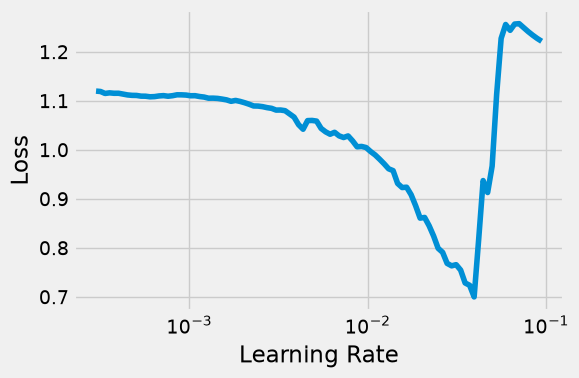

In [134]:
# 程序6-19 测试并参考曲线

# 建议默认模型
torch.manual_seed(13)
new_model = CNN2(n_feature=5, p=0.3)
multi_loss_fn = nn.CrossEntropyLoss(reduction='mean')
new_optimizer = optim.Adam(new_model.parameters(), lr=3e-4)

# 绘制

sbs_new = StepByStep(new_model, multi_loss_fn, new_optimizer)
tracking, fig = sbs_new.lr_range_test(train_loader, end_lr=1e-1, num_iter=100)

In [135]:
# 程序6-20: 从图中挑学习率重新设置优化器
def set_optimizer(self, optimizer):
    self.optimizer = optimizer
    
setattr(StepByStep, 'set_optimizer', set_optimizer)


new_optimizer = optim.Adam(new_model.parameters(), lr=0.005)
sbs_new.set_optimizer(new_optimizer)
sbs_new.set_loaders(train_loader, val_loader)
sbs_new.train(10)

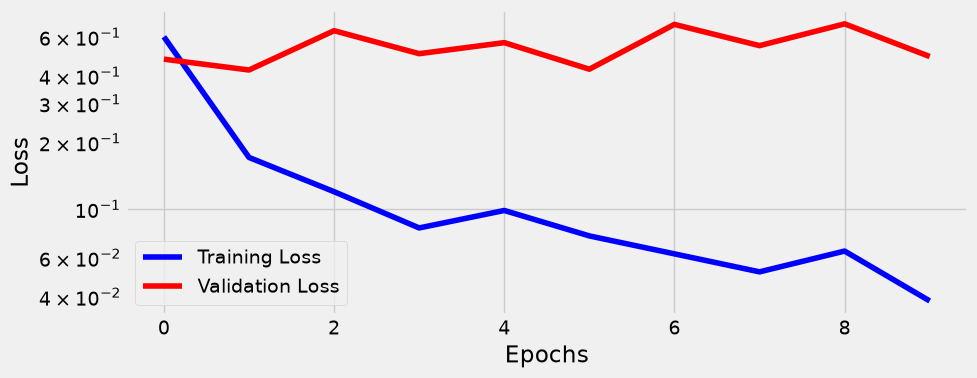

In [136]:
# 测试并检查预想

fig = sbs_new.plot_losses()

## LRFinder

结合代码:

**Q**: 解释`LRFinder`的代码

  0%|          | 0/100 [00:00<?, ?it/s]

Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 9.02E-03


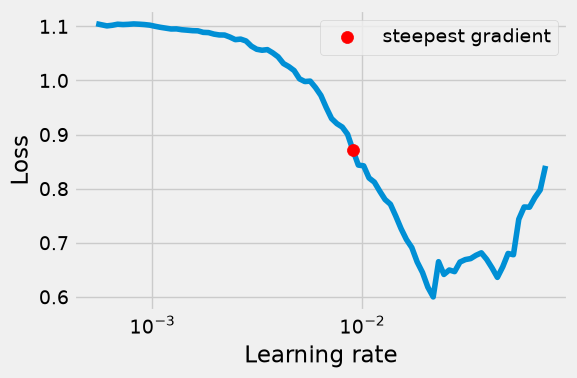

In [137]:
# 程序6-21: 使用第三方库 torch_lr_finder 执行 LR 范围测试
# 与程序6-18手动实现的 lr_range_test 功能相同，但使用社区成熟的 LRFinder 工具。
# 优势：代码更简洁、功能更完善（自动处理状态保存/恢复、支持对数坐标绘图等）。
#
# LRFinder 的核心方法：
#   range_test(): 执行学习率范围测试，逐步增大学习率并记录损失
#   plot():       绘制"学习率-损失"曲线，log_lr=True 表示横轴使用对数刻度
#   reset():      将模型和优化器恢复到测试前的状态（与手动保存/恢复等同）
from torch_lr_finder import LRFinder

# 创建图形对象，用于后续绘制 LR 范围测试的结果曲线
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# 重新初始化模型、损失函数和优化器（使用固定种子保证可复现）
torch.manual_seed(11)
new_model = CNN2(n_feature=5, p=0.3)
multi_loss_fn = nn.CrossEntropyLoss(reduction='mean')
new_optimizer = optim.Adam(new_model.parameters(), lr=3e-4)
# 自动检测可用设备（优先使用 GPU）
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 创建 LRFinder 实例并执行范围测试
lr_finder = LRFinder(new_model, new_optimizer, multi_loss_fn, device=device)
# 在训练集上运行范围测试，学习率从当前值逐步增大到 0.1，共 100 个迭代步
lr_finder.range_test(train_loader, end_lr=1e-1, num_iter=100)
# 绘制"学习率-损失"曲线，log_lr=True 表示横轴（学习率）使用对数刻度
lr_finder.plot(ax=ax, log_lr=True)

fig.tight_layout()
# 测试完成后恢复模型和优化器到初始状态，避免测试过程影响后续训练
lr_finder.reset()

# BTW(ByTheWay)

接下来,要倒回来看看平滑损失和各种优化器是什么情况了

# 自适应学习率

**Q**: Adam调整的是什么？是学习率嘛？

**Q**: 动量和SGD是什么关系？

**Q**: Adam和SGD（动量）和RMSProp有什么关系？



## 移动平均值和指数加权移动平均值

**Q**: 什么是移动平均值？

**Q**: 什么是年龄？

**Q**: 如何计算平均年龄？

**Q**: 什么是指数加权移动平均值？

**Q**: 什么是滞后lag?

**Q**: 什么是偏差校正的EWMA？


结合图：

**Q**: EWMA的平均年龄如何计算？可有证明？

**Q**: 如何推到出周期和α参数的关系？（Tips:平均年龄的计算）

---


结合代码:

**Q**: 如何实现EWMA？

**Q**: 如何实现偏差校正的EWMA？

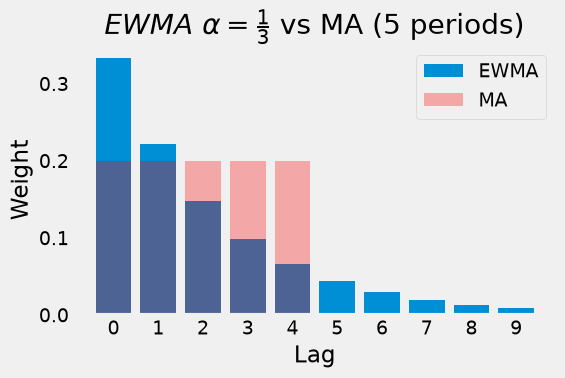

In [138]:
# 可视化对比EWMA和普通MA
# 图像是每个lag对平均值的贡献
fig = figure15()

In [139]:
# 数字证明EWMA平均年龄公式

alpha = 1/3; T = 93
t = np.arange(1, T + 1)
age = alpha * sum((1 - alpha)**(t - 1) * t)
print(age)


3.0


In [140]:
# 程序6-22: 指数加权移动平均（EWMA / EMA）
# EWMA 是一种对序列数据进行平滑处理的方法，广泛应用于：
#   1. 损失曲线平滑 — 减少 mini-batch 之间的随机噪声，使训练趋势更清晰
#   2. 优化器（如 Adam、RMSProp）— 用 EWMA 估计梯度的一阶矩和二阶矩
#   3. 学习率范围测试 — 平滑损失值，避免单个批次的异常值干扰曲线判断
#
# 核心思想：越近的数据点权重越大，越远的数据点权重按指数衰减
#   smoothed_t = α × current_t + (1-α) × smoothed_{t-1}
#
# α 的含义：
#   α 较大（接近1）→ 更关注近期数据，曲线更"抖"但响应快
#   α 较小（接近0）→ 更多保留历史信息，曲线更平滑但滞后多

def EWMA(past_value, current_value, alpha):
    # 单步 EWMA 计算
    # past_value:  上一步的平滑值（即 smoothed_{t-1}）
    # current_value: 当前时刻的原始观测值
    # alpha: 平滑系数，取值范围 (0, 1]
    # 返回: 当前步的平滑值
    # 公式: (1-α) * 过去平滑值 + α * 当前值
    #   等价于: 过去平滑值 + α * (当前值 - 过去平滑值)  ← 修正量的视角
    return (1 - alpha) * past_value + alpha * current_value


def calc_ewma(values, period):
    # 对一整段序列计算 EWMA
    # values: 原始序列（如每个批次的损失值列表）
    # period: 平滑周期 → 用于计算 α = 2 / (period + 1)
    #         这是常用的经验公式（源自期数与权重的对应关系），
    #         例如 period=19 → α=0.1，表示约 19 步的"平均年龄"
    #         此公式在 TensorBoard 的损失平滑中也使用
    # 返回: 与输入等长的平滑后序列（numpy 数组）
    alpha = 2 / (period + 1)
    result = []
    for v in values:
        try:
            # 取上一步的平滑值作为 past_value
            prev_value = result[-1]
        except IndexError:
            # 第一个值没有历史，使用 0 作为初始值（bias correction 的替代方案）
            # 这意味着第一个平滑值 = α × v₁，会比真实值偏小
            # 如果需要更精确的结果，可以在前期做偏差校正
            prev_value = 0

        new_value = EWMA(prev_value, v, alpha)
        result.append(new_value)
    return np.array(result)

In [141]:
# 程序6-23: 偏差校正的 EWMA（Bias-Corrected EWMA）
# 普通 EWMA（程序6-22）在初始阶段存在偏差问题：
#   初始值设为 0 → 第一个平滑值 = α × v₁，远小于真实值 v₁
#   前几步的估计值系统性地偏低，随着迭代增多才逐渐收敛
#
# 偏差校正的原理（源自 Adam 优化器论文，Kingma & Ba 2014）：
#   在步骤 t 时，EWMA 实际上是所有历史值的加权和：
#     smoothed_t = α × Σ[(1-α)^(t-i) × v_i]   （i 从 1 到 t）
#   所有权重之和 = 1 - (1-α)^t = 1 - β^t  （β = 1-α，衰减因子）
#   由于初始为 0，权重之和小于 1 → 除以权重之和即可纠正偏差
#   校正值 = smoothed_t / (1 - β^t)
#
# 效果：
#   步骤 1: β^1 = 0.9, 除以 0.1 → 放大 10 倍（补偿最显著）
#   步骤 10: β^10 ≈ 0.35, 除以 0.65 → 放大约 1.5 倍
#   步骤 50: β^50 ≈ 0.005, 除以 0.995 → 几乎不需要校正
#   随着 t 增大，β^t → 0，校正因子 → 1，校正效果逐渐消失

def correction(averaged_value, beta, steps):
    # 单步偏差校正
    # averaged_value: 未经校正的 EWMA 平滑值
    # beta: 衰减因子 = 1 - alpha（即 (1-α)）
    # steps: 当前步数 t（从1开始计数）
    # 返回: 校正后的值 = averaged_value / (1 - β^t)
    # 例如: beta=0.9, steps=1, averaged_value=α×v₁
    #   → correction = α×v₁ / (1-0.9) = 10×α×v₁ → 补偿了初始偏差
    return averaged_value / (1 - (beta ** steps))


def calc_corrected_ewma(values, period):
    # 对整段序列计算偏差校正的 EWMA
    # values: 原始序列（如每个批次的损失值）
    # period: 平滑周期，用于计算 α = 2/(period+1)
    #
    # 流程：
    #   1. 先用普通 EWMA 计算平滑值（calc_ewma，初始值=0）
    #   2. 再对每一步应用偏差校正，除以 (1 - β^step)
    #
    # 偏差校正让前几步的估计更准确，避免因初始值 0 导致的偏低。
    # 在优化器（Adam）和损失平滑中都可使用。
    ewma = calc_ewma(values, period)

    alpha = 2 / (period + 1)
    beta = 1 - alpha   # 衰减因子：控制历史信息保留的比例

    result = []
    for step, v in enumerate(ewma):
        # step 从 0 开始，所以实际步数为 step + 1
        adj_value = correction(v, beta, step + 1)
        result.append(adj_value)

    return np.array(result)

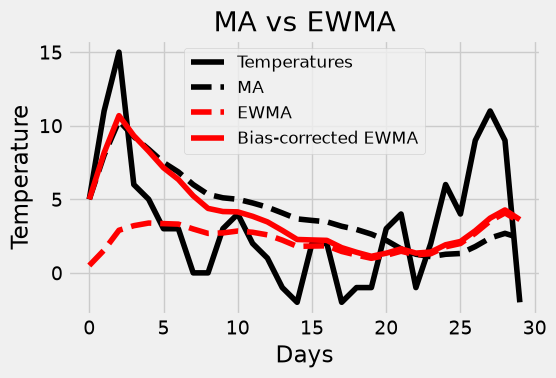

In [142]:
# 可视化对比几个平均值
# 对比三种平滑方式在真实序列上的表现差异：
#   1. 原始数据（无平滑）— 保留所有细节但噪声大
#   2. 普通移动平均（MA）— 窗口内所有值权重相等，对突变响应迟钝
#   3. 指数加权移动平均（EWMA）— 近期值权重更大，响应更快
#
# 下面的气温数据模拟了30天的温度变化（摄氏度），其间有上升、下降和随机波动，
# 这些起伏噪声类似于深度学习训练中 mini-batch 损失值的抖动。
# 通过对比 MA 和 EWMA 的平滑效果，可以直观理解 EWMA 为何更适合用于损失曲线的平滑。

# 模拟30天的气温数据（摄氏度）
temperatures = np.array([5, 11, 15, 6, 5, 3, 3, 0, 0, 3, 4, 2, 1, 
    -1, -2, 2, 2, -2, -1, -1, 3, 4, -1, 2, 6, 4, 9, 11, 9, -2])

# periods=19 → α = 2/(19+1) = 0.1
# 这意味着 EWMA 的"平均年龄"约为 19 步（约 19 天前的数据权重衰减到很低）。
# 普通 MA 使用等权窗口，对突变响应更迟钝；EWMA 则能更快捕捉趋势变化。
fig = ma_vs_ewma(temperatures, periods=19)

# 自适应梯度

**Q**: 自适应一度如何计算？

**Q**: SGD和Adam的参数更新公式是什么？

## Adam

**Q**: Adam的`weight_dacay`和`amsgrad`的参数意义？

**Q**: 权重衰减是什么？为什么会增加梯度来做权重衰减？

结合代码

**Q**: Adam优化器如何使用？

**Q**: Adam优化器的参数如何设置？

In [143]:
# 程序6-24: Adam 优化器的使用与参数设置
# Adam（Adaptive Moment Estimation）结合了动量（Momentum）和 RMSProp 的思想：
#   1. 一阶矩（动量）— 累积过去的梯度方向，加速收敛、减少震荡
#   2. 二阶矩（自适应学习率）— 累积过去的梯度平方，为每个参数自动调节步长
#
# betas=(0.9, 0.999) 是两个指数加权移动平均（EWMA）的衰减因子：
#   beta1=0.9  → 一阶矩衰减率，控制梯度的"动量"
#                 α=1-0.9=0.1，平均年龄≈10步
#                 太小→方向太"短视"，失去动量意义
#                 太大→方向太"粘滞"，对变化响应迟钝
#   beta2=0.999 → 二阶矩衰减率，控制梯度平方的"自适应缩放"
#                 α=1-0.999=0.001，平均年龄≈1000步
#                 需要长期统计因为：单个批次的梯度平方波动极大，
#                 只有大量样本才能稳定估计每个参数的"典型梯度幅度"
#                 太小→自适应学习率波动剧烈，训练不稳定
#                 太大→自适应调节反应过慢
#
# 为什么 beta1≠beta2？设计思想：
#   梯度方向（一阶矩）可以变 — 动量只需短期记忆，0.9 约记19步
#   梯度幅度（二阶矩）应该稳 — 自适应需要长期统计，0.999 约记1999步
#   这是 Adam 论文（Kingma & Ba, 2014）的默认值，对绝大多数任务适用
#
# lr=0.0125:  学习率，经 LR 范围测试（程序6-19~6-20）挑选
# eps=1e-8:   数值稳定性常数，防止除以零（二阶矩估计 v_t 可能接近0）
optimizer = optim.Adam(model_cnn2.parameters(), lr=0.0125, betas=(0.9, 0.999), eps=1e-8)

# 可视化自适应梯度

使用简单线性回归数据集来说宁不同参数对最小化损失二影响

In [144]:
# 数据生成和准备
%run -i ../data_generation/simple_linear_regression.py
%run -i ../data_preparation/v2.py

In [145]:
# 模型配置

torch.manual_seed(42)
model = nn.Sequential()
model.add_module('linear', nn.Linear(1, 1))
optimizer = optim.Adam(model.parameters(), lr=0.1)
loss_fn = nn.MSELoss(reduction='mean')

In [146]:
# 程序6-25: 捕捉梯度（Capture Gradients）
# 利用 PyTorch 的 hook 机制，在反向传播过程中自动记录指定层的参数梯度。
# 这对于分析梯度分布、诊断梯度消失/爆炸、可视化训练过程非常有价值。
#
# PyTorch 的 hook 机制：
#   register_hook(fn) 会在每次计算完该张量的梯度后自动调用 fn(grad)，
#   hook 函数接收梯度张量作为参数，可以在不影响反向传播的前提下
#   记录、查看或修改梯度值。
#
# 整体流程：
#   1. 通过 named_modules() 遍历模型的所有子模块
#   2. 对指定的层，遍历其 named_parameters()（含 weight 和 bias）
#   3. 为每个需要梯度的参数注册一个 hook（log_fn）
#   4. hook 被调用时，将梯度值追加到 self._gradients[name][parm_id] 列表中

# 初始化实例属性 _gradients（存储捕获的梯度值）和 handles（存储 hook 句柄以便后续移除）
setattr(StepByStep, '_gradients', {})

def capture_gradients(self, layers_to_hook):
    # layers_to_hook: 要捕获梯度的层名称列表，如 ['linear'] 或 ['conv1', 'conv2']
    #                 统一转为列表格式，方便后续遍历
    if not isinstance(layers_to_hook, list):
        layers_to_hook = [layers_to_hook]

    # 获取模型的所有命名模块（如 ('linear', Linear(in_features=1, out_features=1))）
    modules = list(self.model.named_modules())
    # 重置梯度存储字典，每次调用 capture_gradients 时清空旧数据
    self._gradients = {}
    
    # 内部函数：为指定参数创建梯度记录函数（闭包）
    # name:    层名称，如 'linear'
    # parm_id: 参数名称，如 'weight' 或 'bias'
    def make_log_fn(name, parm_id):
        # 返回一个 hook 函数，该函数在梯度计算后被自动调用
        def log_fn(grad):
            # 将梯度张量转为 Python 列表后追加到存储中
            # 注意：grad 是二维张量，tolist() 会转为嵌套列表
            self._gradients[name][parm_id].append(grad.tolist())
            return  # hook 函数不需要返回值（或返回修改后的梯度）
        return log_fn

    # 遍历模型的所有命名模块
    for name, layer in self.model.named_modules():
        # 只处理用户指定的层
        if name in layers_to_hook:
            # 为该层初始化梯度存储字典：{ 'weight': [], 'bias': [] }
            self._gradients.update({name: {}})
            # 遍历该层的所有参数（weight 和 bias）
            for parm_id, p in layer.named_parameters():
                # 只对需要梯度的参数注册 hook（requires_grad=True 的参数）
                if p.requires_grad:
                    # 为该参数初始化一个空列表，用于存储每步的梯度值
                    self._gradients[name].update({parm_id: []})
                    # 创建针对该参数的 log_fn
                    log_fn = make_log_fn(name, parm_id)
                    # 注册 hook：注册后 log_fn 会在每次 backward() 时被自动调用
                    # 返回的句柄保存在 handles 字典中，key 格式如 'linear.weight.grad'
                    # 保存句柄是为了后续可以通过 handle.remove() 取消 hook
                    self.handles[f'{name}.{parm_id}.grad'] = p.register_hook(log_fn)
    return

setattr(StepByStep, 'capture_gradients', capture_gradients)

In [147]:
# 测试并捕捉梯度
sbs_adam = StepByStep(model, loss_fn, optimizer)
sbs_adam.set_loaders(train_loader, val_loader)
sbs_adam.capture_gradients('linear')
sbs_adam.train(10)
sbs_adam.remove_hooks()

In [148]:
# 计算EWMA和自适应梯度
gradients = np.array(sbs_adam._gradients['linear']['weight']).squeeze()
corrected_gradients = calc_corrected_ewma(gradients, 19)
corrected_sq_gradients = calc_corrected_ewma(np.power(gradients, 2), 1999)
adapted_gradients = corrected_gradients / (np.sqrt(corrected_sq_gradients) + 1e-8)

print(gradients.shape)
print(corrected_gradients.shape)
print(corrected_sq_gradients.shape)
print(adapted_gradients.shape)

(50,)
(50,)
(50,)
(50,)


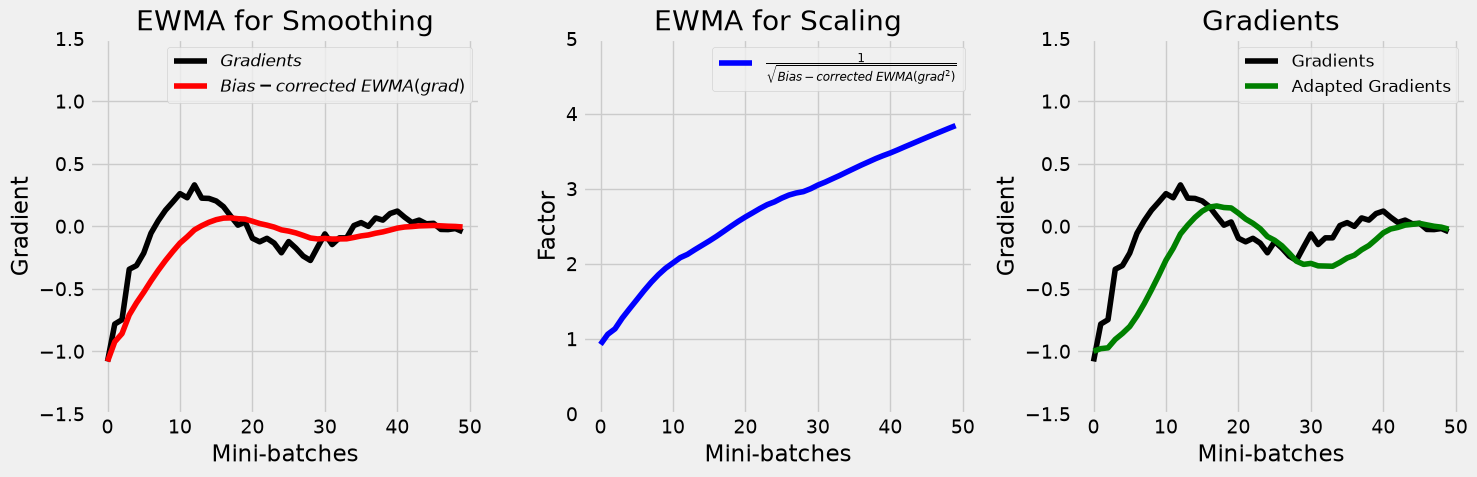

In [149]:
# 可视化结果
fig = figure17(gradients, corrected_gradients, corrected_sq_gradients, adapted_gradients)

In [150]:
# 检查参数: Adam的梯度和平方梯度的EWMA
print(optimizer.state_dict())

{'state': {0: {'step': tensor(50.), 'exp_avg': tensor([[-0.0062]]), 'exp_avg_sq': tensor([[0.0033]])}, 1: {'step': tensor(50.), 'exp_avg': tensor([0.0405]), 'exp_avg_sq': tensor([0.0097])}}, 'param_groups': [{'lr': 0.1, 'betas': (0.9, 0.999), 'eps': 1e-08, 'weight_decay': 0, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': False, 'params': [0, 1]}]}


In [151]:
# 计算EWMA

# 打印最后一个，可以和上述参数做对比
print(calc_ewma(gradients, 19)[-1], calc_ewma(np.power(gradients, 2), 1999)[-1])

-0.006161476466002255 0.003308466907084168


In [152]:
# 捕捉参数

setattr(StepByStep, '_parameters', {})

def capture_parameters(self, layers_to_hook):
    if not isinstance(layers_to_hook, list):
        layers_to_hook = [layers_to_hook]

    modules = list(self.model.named_modules())
    layer_names = {layer: name for name, layer in modules}
    
    self._parameters = {}
    
    for name, layer in modules:
        if name in layers_to_hook:
            self._parameters.update({name: {}})
            for parm_id, p in layer.named_parameters():
                self._parameters[name].update({parm_id: []})
            
    def fw_hook_fn(layer, inputs, outputs):
        name = layer_names[layer]
        for parm_id, parameter in layer.named_parameters():
            self._parameters[name][parm_id].append(parameter.tolist())
    
    self.attach_hooks(layers_to_hook, fw_hook_fn)
    return
    
setattr(StepByStep, 'capture_parameters', capture_parameters)

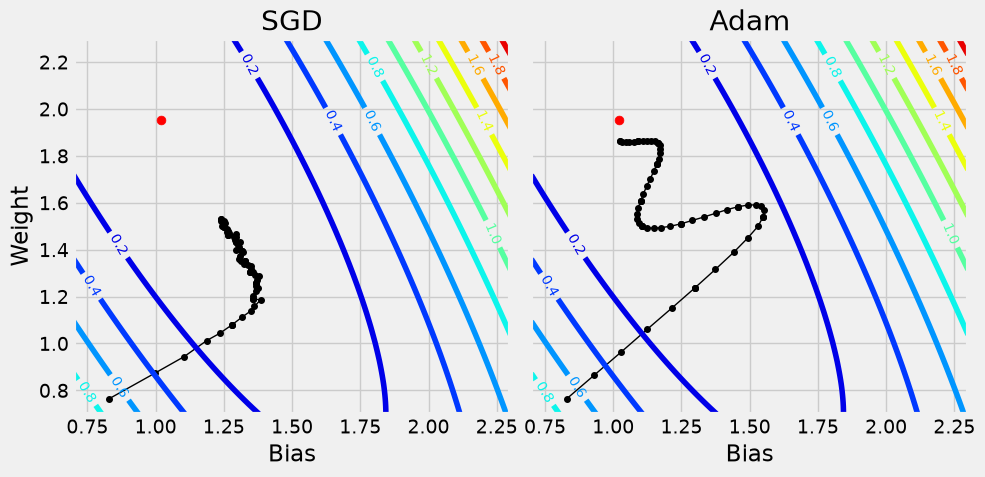

In [153]:
# 可视化SGD和Adam的参数

torch.manual_seed(42)
model = nn.Sequential()
model.add_module('linear', nn.Linear(1, 1))
loss_fn = nn.MSELoss(reduction='mean')

optimizers = {'SGD': {'class': optim.SGD, 'parms': {'lr': 0.1}}, 
             'Adam': {'class': optim.Adam, 'parms': {'lr': 0.1}}}
results = compare_optimizers(model, loss_fn, optimizers, train_loader, val_loader, n_epochs=10)

b, w, bs, ws, all_losses = contour_data(x_tensor, y_tensor)
fig = plot_paths(results, b, w, bs, ws, all_losses)

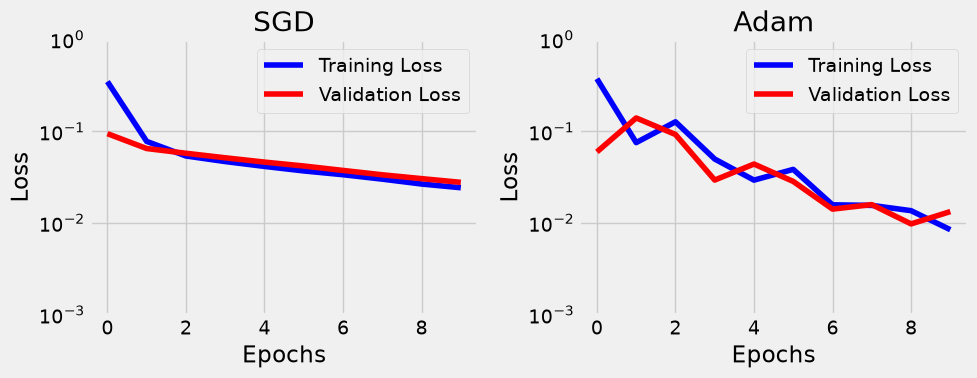

In [154]:
# 可视化损失变化
fig = plot_losses(results)

## 随机梯度下降(SGD)和动量

**Q**: 动量公式如何？和EWMA公式有什么区别？

**Q**: 合成动量公式如何？

**Q**: 带阻尼因子的动量公式如何？

**Q**: 动量的更新参数公式是什么？

结合代码:

**Q**: SGD保存了动量的那些信息？

In [155]:
# 生成可视化动量
torch.manual_seed(42)
model = nn.Sequential()
model.add_module('linear', nn.Linear(1, 1))
loss_fn = nn.MSELoss(reduction='mean')

optimizers = {'SGD': {'class': optim.SGD, 'parms': {'lr': 0.1}}, 
             'SGD + Momentum': {'class': optim.SGD, 'parms': {'lr': 0.1, 'momentum': 0.9}}}

results = compare_optimizers(model, loss_fn, optimizers, train_loader, val_loader, n_epochs=10)

results['SGD + Momentum']['state']

{'state': {0: {'momentum_buffer': tensor([[-0.0308]])},
  1: {'momentum_buffer': tensor([-0.1423])}},
 'param_groups': [{'lr': 0.1,
   'momentum': 0.9,
   'dampening': 0,
   'weight_decay': 0,
   'nesterov': False,
   'maximize': False,
   'foreach': None,
   'differentiable': False,
   'fused': None,
   'params': [0, 1]}]}

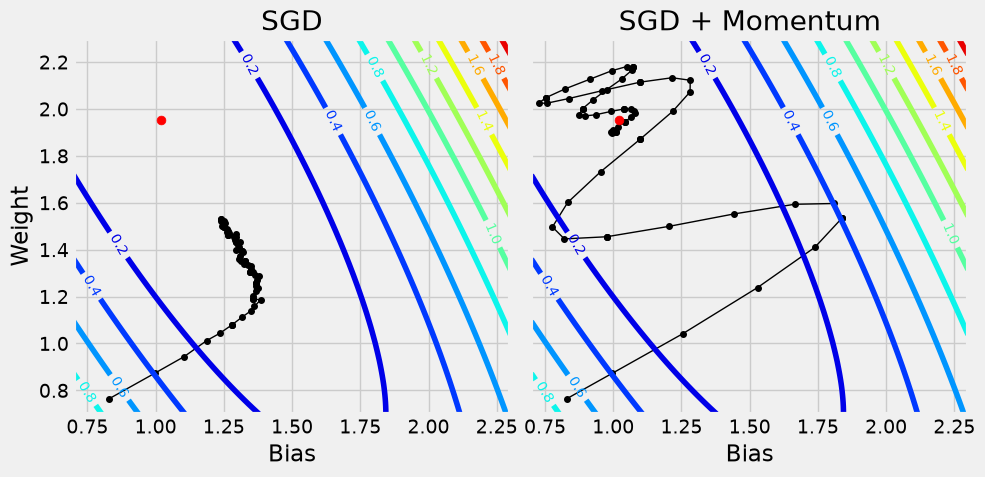

In [156]:
fig = plot_paths(results, b, w, bs, ws, all_losses)

## 随机梯度下降(SGD)和加速梯度Nesterov(NAG)

**Q**: Nestrov如何从动量公式推导？（Tips:预测t+1）

**Q**: Nestrov+SGD的公式和SGD公式的区别？

结合图：

**Q**: 分析图表表示的信息

In [157]:
# 生成图像
torch.manual_seed(42)
model = nn.Sequential()
model.add_module('linear', nn.Linear(1, 1))
loss_fn = nn.MSELoss(reduction='mean')

optimizers = {'SGD': {'class': optim.SGD, 'parms': {'lr': 0.1}}, 
              'SGD + Momentum': {'class': optim.SGD, 'parms': {'lr': 0.1, 'momentum': 0.9}},
              'SGD + Nesterov': {'class': optim.SGD, 'parms': {'lr': 0.1, 'momentum': 0.9, 'nesterov': True}}}

results = compare_optimizers(model, loss_fn, optimizers, train_loader, val_loader, n_epochs=10)

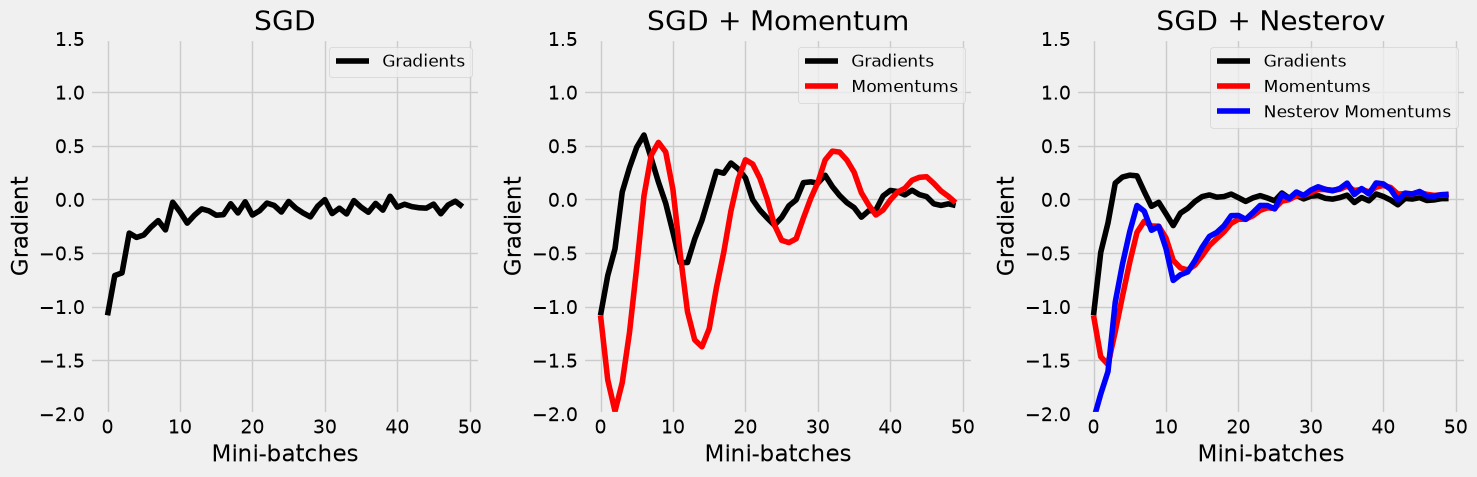

In [158]:
# 可视化结果
fig = figure21(results)

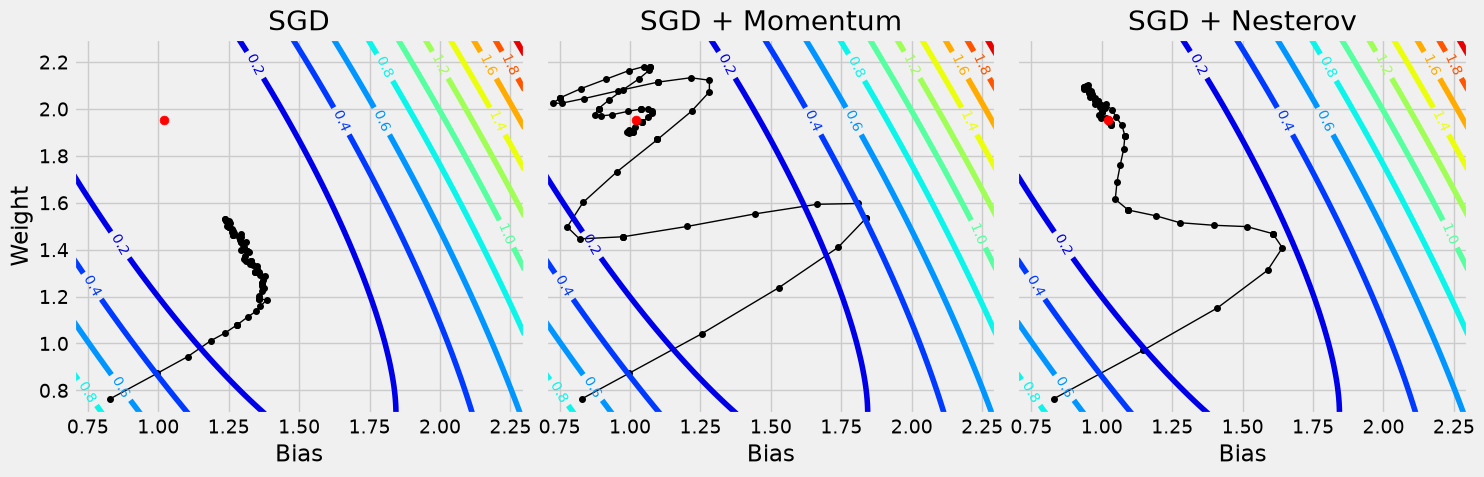

In [159]:
# 可视化结果
fig = plot_paths(results, b, w, bs, ws, all_losses)

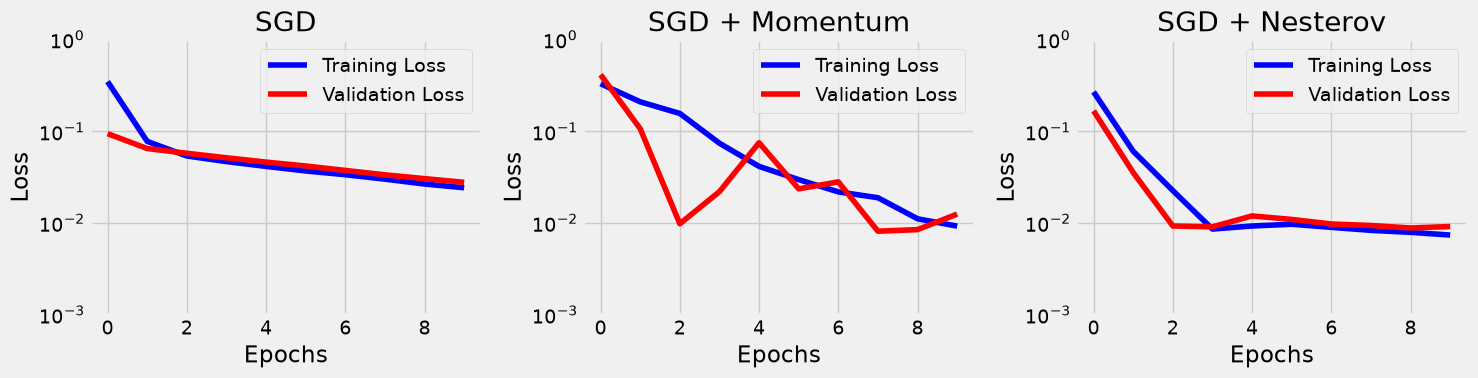

In [160]:
# 可视化结果
fig = plot_losses(results)

# 学习率与调度器(Schedulers)

**Q**: 调度器的种类

In [161]:
# Step调度器的创建

dummy_optimizer = optim.SGD([nn.Parameter(torch.randn(1))], lr=0.01)
dummy_scheduler = StepLR(dummy_optimizer, step_size=2, gamma=0.1)

In [162]:
# 测试结果
for epoch in range(4):
    # trainin loop code goes here
    
    print(dummy_scheduler.get_last_lr())
    # First call optimizer's step
    dummy_optimizer.step()
    # Then call scheduler's step
    dummy_scheduler.step()
    
    dummy_optimizer.zero_grad()

[0.01]
[0.01]
[0.001]
[0.001]


## epoch 调度器

**Q**: epoch调度器的更新时机是什么？


In [163]:
dummy_optimizer = optim.SGD([nn.Parameter(torch.randn(1))], lr=0.01)
dummy_scheduler = LambdaLR(dummy_optimizer, lr_lambda=lambda epoch: 0.1 ** (epoch//2))

# 等价于如下代码
# dummy_scheduler = StepLR(dummy_optimizer, step_size=2, gamma=0.1)

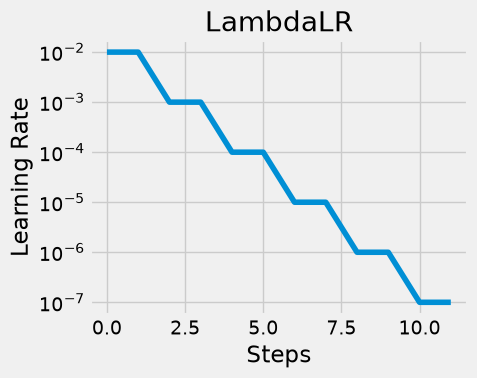

In [164]:
fig = plot_scheduler(dummy_optimizer, dummy_scheduler)

## 验证损失(Validation Loss)调度器

**Q**: 验证损失调度器的更新逻辑是什么？

In [165]:
dummy_optimizer = optim.SGD([nn.Parameter(torch.randn(1))], lr=0.01)
dummy_scheduler = ReduceLROnPlateau(dummy_optimizer, patience=4, factor=0.1)

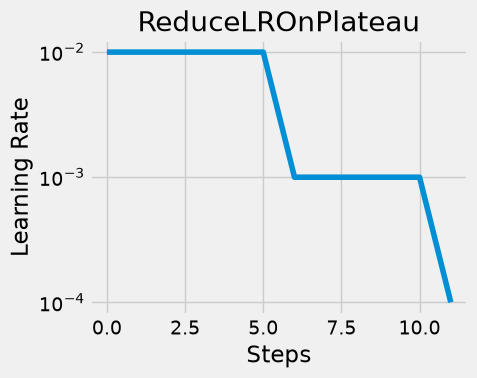

In [166]:
fig = plot_scheduler(dummy_optimizer, dummy_scheduler)

## Mini-Batch 调度器

**Q**: Mini-Batch调度器的更新逻辑是什么？

**Q**: step_size_up的设置范围应该是什么？为什么？

In [167]:
# Mini-batch循环调度器
dummy_parm = [nn.Parameter(torch.randn(1))]
dummy_optimizer = optim.SGD(dummy_parm, lr=0.01)

dummy_scheduler1 = CyclicLR(dummy_optimizer, base_lr=1e-4, max_lr=1e-3, step_size_up=2, mode='triangular')
dummy_scheduler2 = CyclicLR(dummy_optimizer, base_lr=1e-4, max_lr=1e-3, step_size_up=2, mode='triangular2')
dummy_scheduler3 = CyclicLR(dummy_optimizer, base_lr=1e-4, max_lr=1e-3, step_size_up=2, mode='exp_range', gamma=np.sqrt(.5))

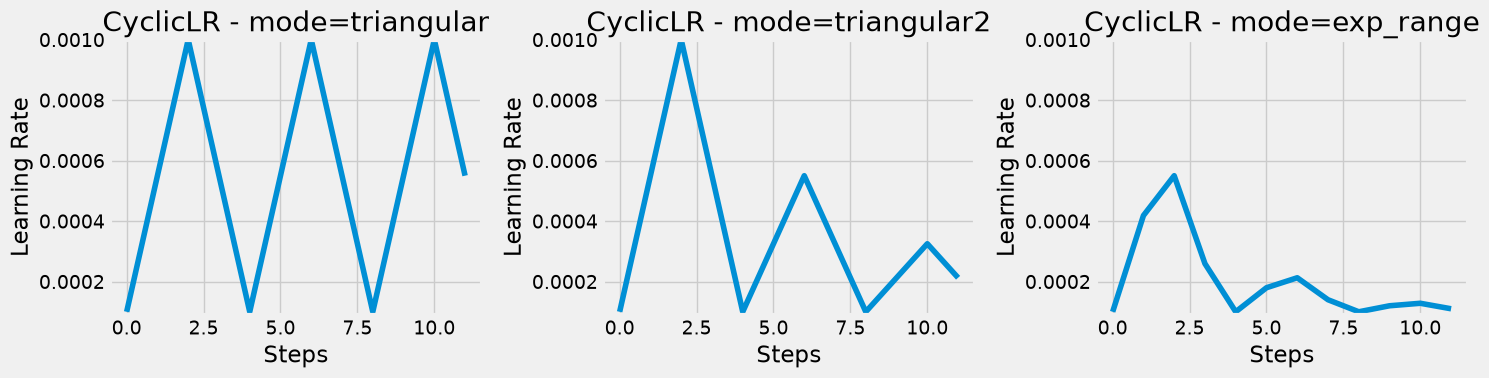

In [168]:
fig = figure26(dummy_optimizer, (dummy_scheduler1, dummy_scheduler2, dummy_scheduler3))

## Schedulers in StepByStep

结合代码：

**Q**: 检查函数用途

In [169]:
# ============================================================
# set_lr_scheduler: 设置学习率调度器
# 用途：将外部创建的调度器绑定到当前 StepByStep 实例的优化器上，
#       并自动识别该调度器是 epoch 级别还是 batch 级别的调度器，
#       以便后续在正确的时机调用 scheduler.step()
# ============================================================
setattr(StepByStep, 'scheduler', None)
setattr(StepByStep, 'is_batch_lr_scheduler', False)

def set_lr_scheduler(self, scheduler):
    # 确保传入的调度器绑定的是当前 StepByStep 使用的优化器
    if scheduler.optimizer == self.optimizer:
        self.scheduler = scheduler
        # 判断调度器类型：CyclicLR、OneCycleLR、CosineAnnealingWarmRestarts
        # 是 mini-batch 级别的调度器（每个 batch 后更新学习率），
        # 其余为 epoch 级别的调度器（每个 epoch 后更新学习率）
        if (isinstance(scheduler, optim.lr_scheduler.CyclicLR) or
            isinstance(scheduler, optim.lr_scheduler.OneCycleLR) or
            isinstance(scheduler, optim.lr_scheduler.CosineAnnealingWarmRestarts)):
            self.is_batch_lr_scheduler = True
        else:
            self.is_batch_lr_scheduler = False

setattr(StepByStep, 'set_lr_scheduler', set_lr_scheduler)

In [170]:
# ============================================================
# _epoch_schedulers: epoch 级别调度器的更新入口
# 用途：在每个 epoch 结束时被 train() 调用，负责更新 epoch 级别
#       的调度器（如 StepLR、ReduceLROnPlateau、LambdaLR 等）。
#       如果是 ReduceLROnPlateau（基于验证损失的调度器），
#       则将当前验证损失传入 step()；否则直接调用 step()。
#       更新后会记录当前学习率到 self.learning_rates 列表。
# ============================================================
setattr(StepByStep, 'learning_rates', [])

def _epoch_schedulers(self, val_loss):
    if self.scheduler:
        # 只处理 epoch 级别的调度器（batch 级别的在 _mini_batch_schedulers 中处理）
        if not self.is_batch_lr_scheduler:
            # ReduceLROnPlateau 需要传入验证损失作为决策依据
            if isinstance(self.scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                self.scheduler.step(val_loss)
            else:
                # 其他 epoch 调度器（StepLR、LambdaLR、MultiStepLR 等）无需参数
                self.scheduler.step()

            # 记录所有参数组的当前学习率
            current_lr = list(map(lambda d: d['lr'], self.scheduler.optimizer.state_dict()['param_groups']))
            self.learning_rates.append(current_lr)

setattr(StepByStep, '_epoch_schedulers', _epoch_schedulers)

In [171]:
# ============================================================
# train: 完整的训练流程
# 用途：执行 n_epochs 轮训练，每轮包含：
#   1. 训练阶段 — 调用 _mini_batch(validation=False) 更新参数
#   2. 验证阶段 — 调用 _mini_batch(validation=True) 评估模型（不计算梯度）
#   3. 调度器更新 — 调用 _epoch_schedulers(val_loss) 更新学习率
#   4. TensorBoard 记录 — 如果设置了 writer，记录训练/验证损失
# ============================================================
def train(self, n_epochs, seed=42):
    # 设置随机种子，确保训练过程可复现
    self.set_seed(seed)

    for epoch in range(n_epochs):
        # 递增 epoch 计数器，跟踪已完成的训练轮数
        self.total_epochs += 1

        # 内循环
        # 使用 mini-batch 进行训练
        loss = self._mini_batch(validation=False)
        self.losses.append(loss)

        # 验证
        # 验证阶段不需要计算梯度！
        with torch.no_grad():
            # 使用 mini-batch 进行评估
            val_loss = self._mini_batch(validation=True)
            self.val_losses.append(val_loss)

        # 更新 epoch 级别的调度器
        self._epoch_schedulers(val_loss)

        # 如果设置了 SummaryWriter，记录损失到 TensorBoard
        if self.writer:
            scalars = {'training': loss}
            if val_loss is not None:
                scalars.update({'validation': val_loss})
            # 在 "loss" 主标签下记录训练和验证损失
            self.writer.add_scalars(main_tag='loss',
                                    tag_scalar_dict=scalars,
                                    global_step=epoch)

    if self.writer:
        # 关闭 writer，释放资源
        self.writer.close()

setattr(StepByStep, 'train', train)

In [172]:
# ============================================================
# _mini_batch_schedulers: batch 级别调度器的更新入口
# 用途：在每个 mini-batch 训练步骤结束后被 _mini_batch() 调用，
#       负责更新 batch 级别的调度器（CyclicLR、OneCycleLR、
#       CosineAnnealingWarmRestarts）。对于 CosineAnnealingWarmRestarts，
#       需要传入当前的总 epoch 进度（含小数部分）作为 step 的参数。
#       更新后会记录当前学习率到 self.learning_rates 列表。
# ============================================================
def _mini_batch_schedulers(self, frac_epoch):
    if self.scheduler:
        # 只处理 batch 级别的调度器（epoch 级别的在 _epoch_schedulers 中处理）
        if self.is_batch_lr_scheduler:
            # CosineAnnealingWarmRestarts 需要知道当前的 epoch 进度
            # frac_epoch 表示当前 epoch 内已完成的比例（0~1）
            if isinstance(self.scheduler, torch.optim.lr_scheduler.CosineAnnealingWarmRestarts):
                self.scheduler.step(self.total_epochs + frac_epoch)
            else:
                # 其他 batch 调度器（CyclicLR、OneCycleLR）无需参数
                self.scheduler.step()

            # 记录所有参数组的当前学习率
            current_lr = list(map(lambda d: d['lr'], self.scheduler.optimizer.state_dict()['param_groups']))
            self.learning_rates.append(current_lr)

setattr(StepByStep, '_mini_batch_schedulers', _mini_batch_schedulers)

In [173]:
# ============================================================
# _mini_batch: mini-batch 循环的核心实现
# 用途：遍历数据加载器中的每个批次，执行训练或验证步骤。
#   训练模式：调用 train_step_fn 进行前向/反向/参数更新，
#             并在每个 batch 后调用 _mini_batch_schedulers 更新学习率。
#   验证模式：调用 val_step_fn 进行前向/损失计算（不更新参数），
#             不调用调度器。
#   返回：所有批次的平均损失值。
# ============================================================
def _mini_batch(self, validation=False):
    # mini-batch 循环可以用于训练和验证两种模式
    # 参数 validation 决定使用哪个数据加载器和对应的 step 函数
    if validation:
        data_loader = self.val_loader
        step_fn = self.val_step_fn
    else:
        data_loader = self.train_loader
        step_fn = self.train_step_fn

    if data_loader is None:
        return None

    n_batches = len(data_loader)
    # 选定数据加载器和 step 函数后，执行标准的 mini-batch 循环
    mini_batch_losses = []
    for i, (x_batch, y_batch) in enumerate(data_loader):
        x_batch = x_batch.to(self.device)
        y_batch = y_batch.to(self.device)

        # 执行一步训练或验证，返回该批次的损失值
        mini_batch_loss = step_fn(x_batch, y_batch)
        mini_batch_losses.append(mini_batch_loss)

        # 仅在训练模式下更新 batch 级别的调度器
        if not validation:
            # 传入当前 epoch 内的进度比例（i / n_batches）
            self._mini_batch_schedulers(i / n_batches)

    # 返回所有批次的平均损失
    loss = np.mean(mini_batch_losses)
    return loss

setattr(StepByStep, '_mini_batch', _mini_batch)

## 调度器路径



5


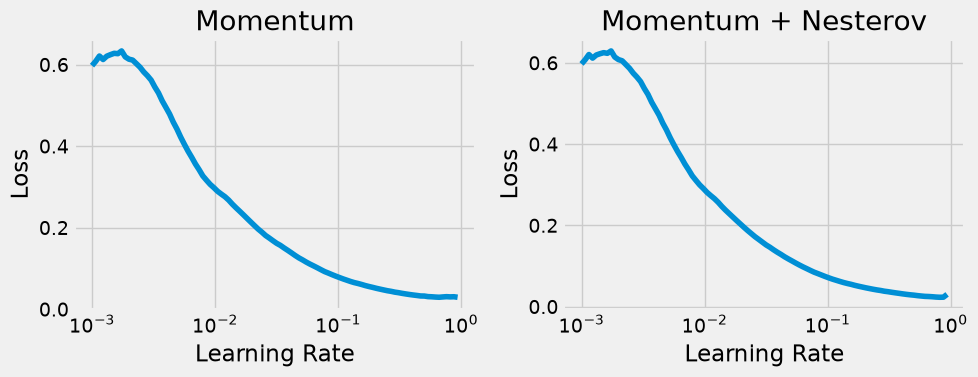

In [174]:
from stepbystep.v3 import StepByStep

print(len(train_loader))
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
for ax, nesterov in zip(axs.flat, [False, True]):
    torch.manual_seed(42)
    model = nn.Sequential()
    model.add_module('linear', nn.Linear(1, 1))
    loss_fn = nn.MSELoss(reduction='mean')
    optimizer = optim.SGD(model.parameters(), lr=1e-3, momentum=0.9, nesterov=nesterov)

    sbs_scheduler = StepByStep(model, loss_fn, optimizer)
    tracking, fig = sbs_scheduler.lr_range_test(train_loader, end_lr=1, num_iter=100, ax=ax)
        
    nest = ' + Nesterov' if nesterov else ''
    ax.set_title(f'Momentum{nest}')

In [ ]:
# 通过LR找出的中间值学习率
step_scheduler = StepLR(optimizer, step_size=20, gamma=0.5)
cyclic_scheduler = CyclicLR(optimizer, base_lr=0.025, max_lr=0.1, step_size_up=10, mode='triangular2')

In [176]:
# Generating data for the plots
torch.manual_seed(42)
model = nn.Sequential()
model.add_module('linear', nn.Linear(1, 1))
loss_fn = nn.MSELoss(reduction='mean')

optimizers = {'SGD + Momentum': {'class': optim.SGD, 'parms': {'lr': 0.1, 'momentum': 0.9}},
              'SGD + Momentum + Step': {'class': optim.SGD, 'parms': {'lr': 0.1, 'momentum': 0.9}},
              'SGD + Momentum + Cycle': {'class': optim.SGD, 'parms': {'lr': 0.1, 'momentum': 0.9}},
              'SGD + Nesterov': {'class': optim.SGD, 'parms': {'lr': 0.1, 'momentum': 0.9, 'nesterov': True}},
              'SGD + Nesterov + Step': {'class': optim.SGD, 'parms': {'lr': 0.1, 'momentum': 0.9, 'nesterov': True}},
              'SGD + Nesterov + Cycle': {'class': optim.SGD, 'parms': {'lr': 0.1, 'momentum': 0.9, 'nesterov': True}}}

schedulers = {'SGD + Momentum + Step': {'class': StepLR, 'parms': {'step_size': 4, 'gamma': 0.5}},
              'SGD + Momentum + Cycle': {'class': CyclicLR, 'parms': {'base_lr': 0.025, 'max_lr': 0.1, 'step_size_up': 10, 'mode': 'triangular2'}},
              'SGD + Nesterov + Step': {'class': StepLR, 'parms': {'step_size': 4, 'gamma': 0.5}},
              'SGD + Nesterov + Cycle': {'class': CyclicLR, 'parms': {'base_lr': 0.025, 'max_lr': 0.1, 'step_size_up': 10, 'mode': 'triangular2'}}}

results = compare_optimizers(model, loss_fn, optimizers, train_loader, val_loader, schedulers, n_epochs=10)

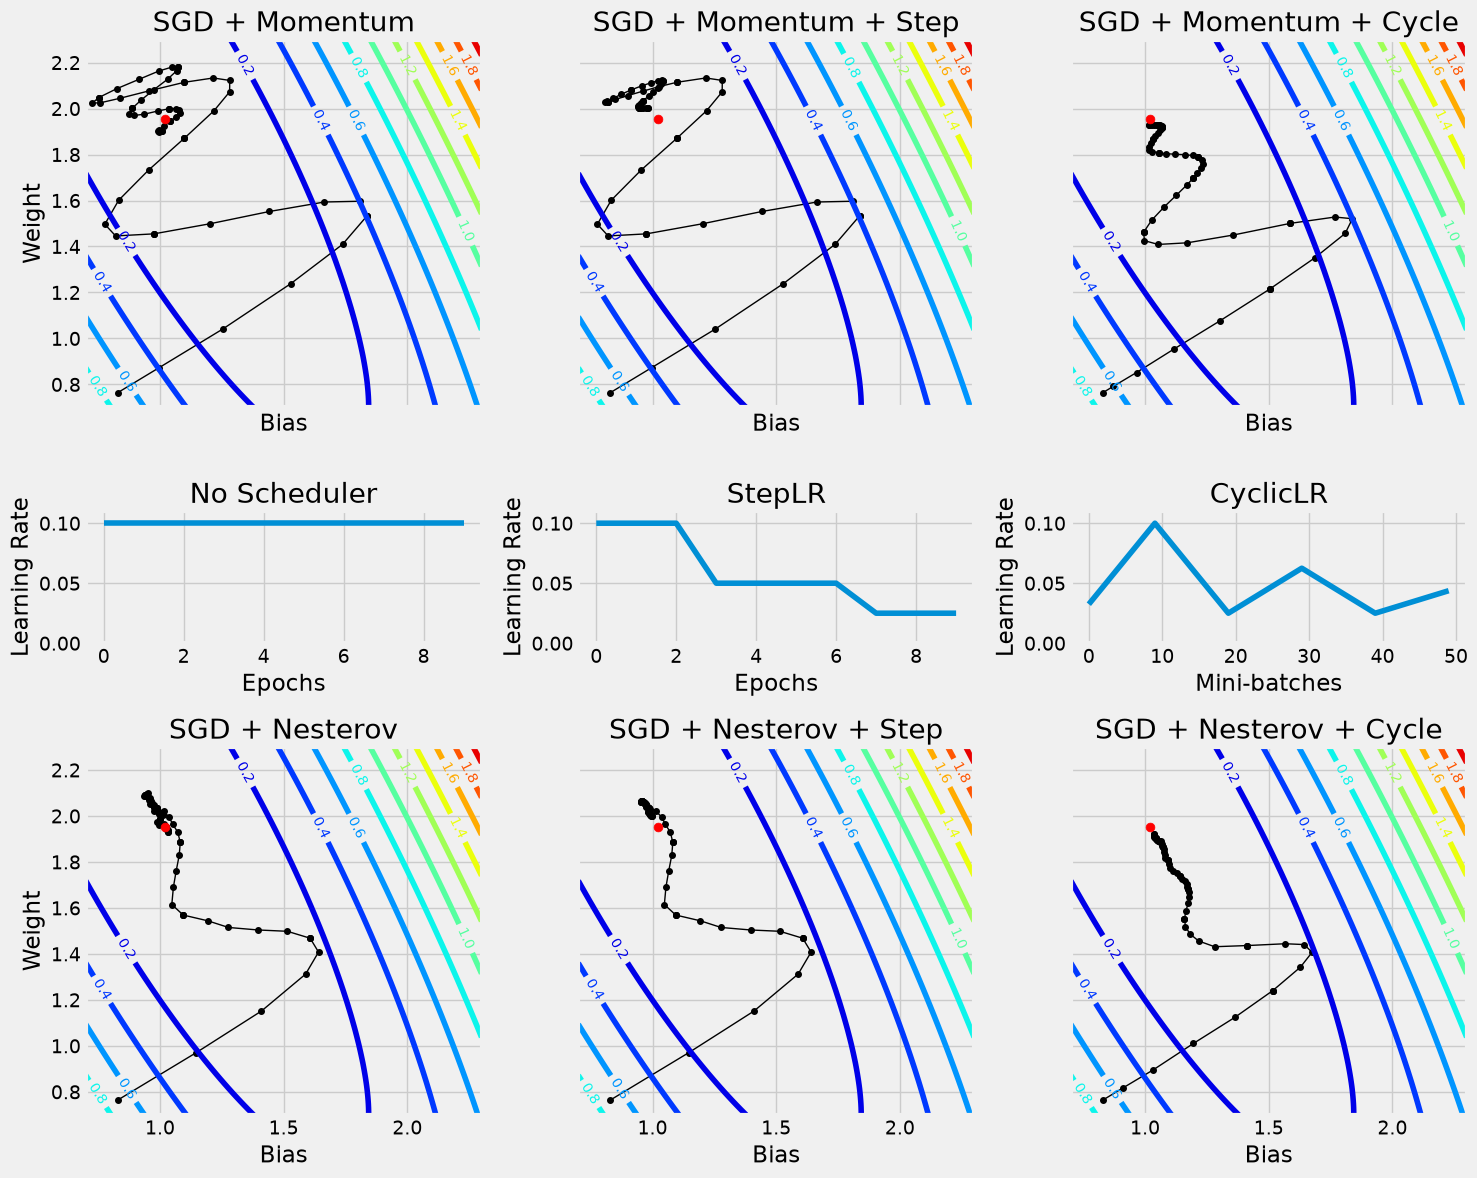

In [177]:
fig = figure28(results, b, w, bs, ws, all_losses)

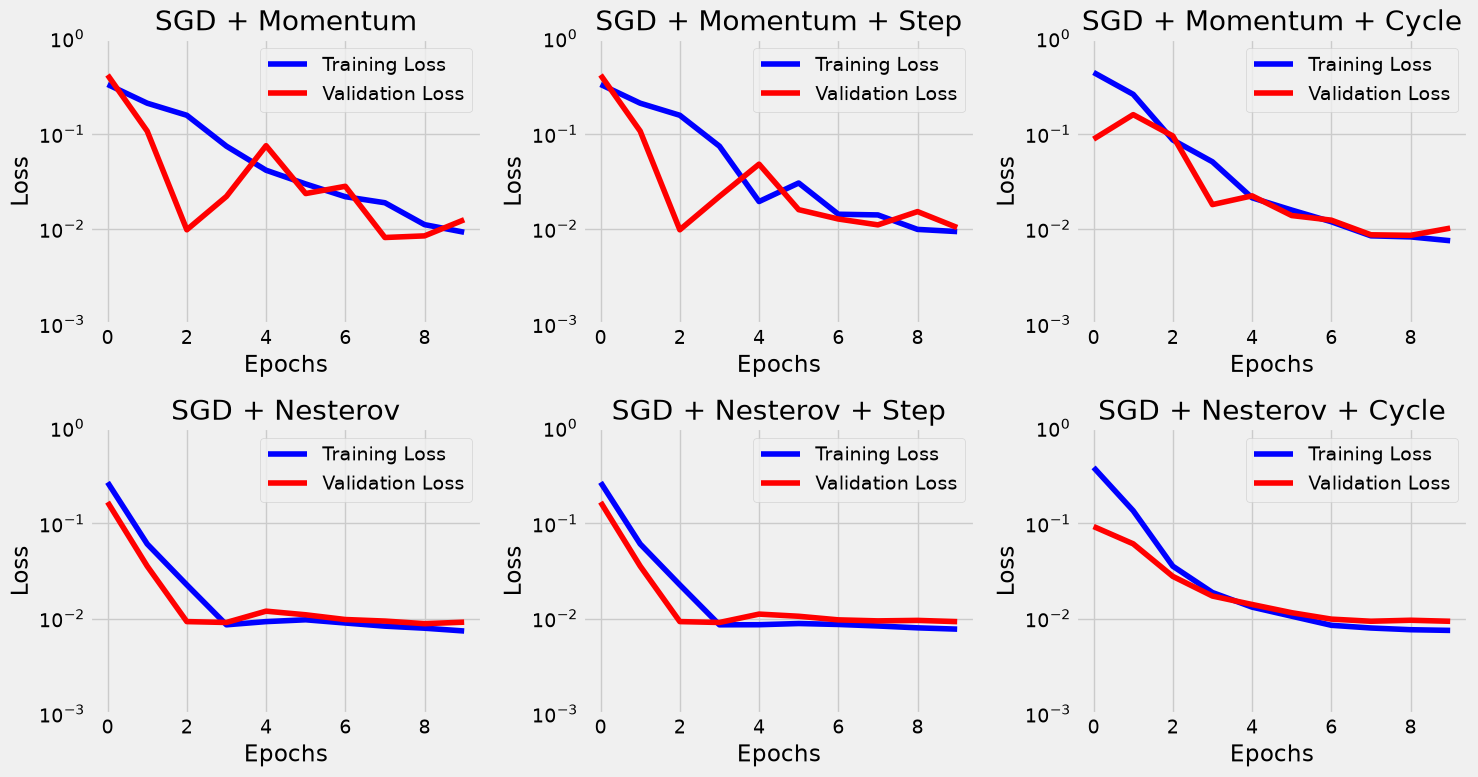

In [178]:
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.flat
fig = plot_losses(results, axs)

# Putting It All Together

In [179]:
# Loads temporary dataset to build normalizer
temp_transform = Compose([Resize(28), ToImage(), ToDtype(torch.float32, scale=True)])
temp_dataset = ImageFolder(root='rps', transform=temp_transform)
temp_loader = DataLoader(temp_dataset, batch_size=16)
normalizer = StepByStep.make_normalizer(temp_loader)

# Builds transformation, datasets and data loaders
composer = Compose([Resize(28),
                    ToImage(), 
                    ToDtype(torch.float32, scale=True),
                    normalizer])

train_data = ImageFolder(root='rps', transform=composer)
val_data = ImageFolder(root='rps-test-set', transform=composer)

# Builds a loader of each set
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16)

In [180]:
torch.manual_seed(13)
model_cnn3 = CNN2(n_feature=5, p=0.5)
multi_loss_fn = nn.CrossEntropyLoss(reduction='mean')
optimizer_cnn3 = optim.SGD(model_cnn3.parameters(), lr=1e-3, momentum=0.9, nesterov=True)

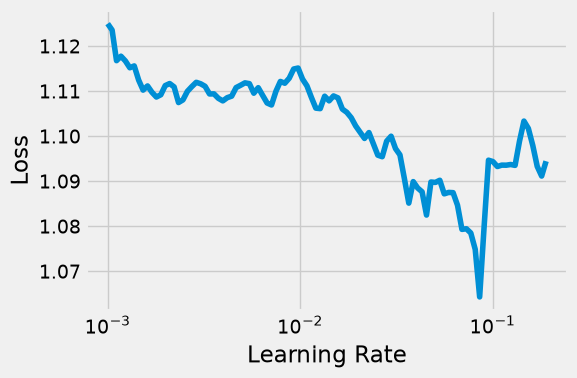

In [181]:
sbs_cnn3 = StepByStep(model_cnn3, multi_loss_fn, optimizer_cnn3)
tracking, fig = sbs_cnn3.lr_range_test(train_loader, end_lr=2e-1, num_iter=100)

In [182]:
optimizer_cnn3 = optim.SGD(model_cnn3.parameters(), lr=0.01, momentum=0.9, nesterov=True)
sbs_cnn3.set_optimizer(optimizer_cnn3)

scheduler = CyclicLR(optimizer_cnn3, base_lr=1e-3, max_lr=0.01, step_size_up=len(train_loader), mode='triangular2')
sbs_cnn3.set_lr_scheduler(scheduler)

In [ ]:
sbs_cnn3.set_loaders(train_loader, val_loader)
sbs_cnn3.train(10)

In [ ]:
fig = sbs_cnn3.plot_losses()

In [ ]:
print(StepByStep.loader_apply(train_loader, sbs_cnn3.correct).sum(axis=0), 
      StepByStep.loader_apply(val_loader, sbs_cnn3.correct).sum(axis=0))